# CC6MM Evolutionary Algorithms - Tarea 2

**Session 2: Genetic Algorithm**

This practical session provides the complete implementation of a genetic algorithm.

Feedback may be sent to Alexandre Bergel (abergel@dcc.uchile.cl) 

Integrantes del grupo:

*   Paola Rioseco
*   José Sanz
*   Guillermo Pinto
*   Guillermo Barriga
*   Manuel Bórquez


## Generative Algorithm

The class `GA` given above provides all the necessary to use genetic algorithm to solve a particular problem. 

In [1]:
import copy
import random

import numpy as np
import string
import inspect

# Define the main class of the genetic algorithm
class GA:
    # pop_size is the size of the population. E.g., 1000
    # mutation_rate is the rate of a gene mutation. E.g., 0.1
    # fitness is a function that takes an individual as argument. E.g. lambda genes: sum(collections.Counter(genes))
    # individual_factory is a lambda that creates an individual. E.g., lambda : [ random.randint(0,10) for i in range(4) ]
    # gene_factory is a function that produces a new gene
    # termination_condition is the termination condition that takes as argument the fitness of the best element. If it returns True, then the algorithm ends
    #   E.g., lambda fitness : fitness >= 3
    # max_iter is the maximum number of iterations
    def __init__(self, pop_size, mutation_rate, fitness, individual_factory, gene_factory, termination_condition,
                 max_iter=100, silent=False):
        self.population_size = pop_size
        self.mutation_rate = mutation_rate
        self.fitness_function = fitness
        self.individualFactory = individual_factory
        self.max_iterations = max_iter
        self.termination_condition = termination_condition
        self.gene_factory = gene_factory
        self.population = list()
        self.individual_fitnesses = list()
        self.silent = silent

    # main method to actually run the algorithm
    # return a tupple best_fitness_list, avg_list, best_individual
    def run(self):
        current_iteration = 0
        best_fitness_list = list()
        worst_fitness_list = list()
        avg_list = list()

        # We generate the initial population
        self.population = self.generate_population()

        # We compute all the fitnesses. It is a collection of fitness values, of the same size than the population
        self.individual_fitnesses = self.get_fitness(self.population)

        # We get the best_individual of the current population
        best_individual = self.get_best_individual()

        # mejor individuo por generaciónmejor individuo por generación
        best_individuals = []


        # We loop if we have not reached the maximum number of iterations and if the termination condition is not met
        while current_iteration <= self.max_iterations and not self.termination_condition(self.fitness_function(best_individual)):
            self.log("iter {} of {}".format(current_iteration, self.max_iterations))

            best_fitness_list.append(max(self.individual_fitnesses))

            # peor fitness por generación
            worst_fitness_list.append(min(self.individual_fitnesses))

            avg_list.append(np.mean(self.individual_fitnesses))

            self.log("best is: {}\nwith: {} worst: {} acc. Avg: {}".format(best_individual, best_fitness_list[-1], worst_fitness_list[-1], avg_list[-1]))

            # we create a new population
            new_population = []
            for _ in range(self.population_size):
                parent1 = self.tournament(self.population)
                parent2 = self.tournament(self.population)
                new_population.append(self.create_new_individual(parent1, parent2))

            self.population = new_population
            self.individual_fitnesses = self.get_fitness(self.population)
            current_iteration += 1
            best_individual = self.get_best_individual()
            
            # mejor individuo por generación
            best_individuals.append(self.get_best_individual())
            
        
        last_fitness = self.get_fitness(self.population)
        best_individual = self.population[last_fitness.index(max(last_fitness))]

        best_fitness_list.append(max(last_fitness))

        # peor fitness por generación
        worst_fitness_list.append(min(last_fitness))

        avg_list.append(np.mean(last_fitness))

        # mejor individuo por generación
        best_individuals.append(best_individual)

        self.log("best found is: {}\nwith: {} worst: {} acc. Avg: {}".format(best_individual, best_fitness_list[-1], worst_fitness_list[-1], avg_list[-1]))

        return best_fitness_list, worst_fitness_list, avg_list, best_individual, best_individuals

     
    # Logging 
    def log(self, aString):
        if not self.silent:
            print(aString)
        
    # return the best individual of the current population
    def get_best_individual(self):
        return self.population[self.individual_fitnesses.index(max(self.individual_fitnesses))]
    
    # retorna el peor individuo de la población actual
    def get_worst_individual(self):
        return self.population[self.individual_fitnesses.index(min(self.individual_fitnesses))]

    # generate the population, made of individuals
    def generate_population(self):
        _population = list()
        for _ in range(self.population_size):
            _population.append(self.individualFactory())
        return _population

    # Return the list of the fitness values for the population
    def get_fitness(self, aPopulation):
        return list(map(self.fitness_function, aPopulation))

    # Obtain the best individual from a tournament on the population
    def tournament(self, aPopulation, k = 5):
        best = None
        best_fitness = -1
        for _ in range(1, k):
            ind = random.choice(aPopulation)
            if(best is None or (self.fitness_function(ind) > best_fitness)):
                best = ind
                best_fitness = self.fitness_function(ind)
        return best

    # create a new individual from two parents elements
    def create_new_individual(self, parent1, parent2):
        final_child = self.crossover(parent1, parent2)
        # mutation
        if random.random() < self.mutation_rate:
            self.mutate(final_child)
        return final_child

    # crossover operation
    # crossover([1,2,3,4], [10,20,30,40])
    # => [1, 20, 30, 40]
    def crossover(self, individual1, individual2):
        _tmp = random.randint(1, len(individual1))
        return individual1[:_tmp] + individual2[_tmp:]

    # Mutate an individual
    # Note that this method does a side effect. I.e., it does not create a new individual
    def mutate(self, an_individual):
        index = random.randrange(len(an_individual))
        #an_individual[index] = self.gene_factory()
        # compatibilidad con gene_factory que acepta índice
        try:
            # si gene_factory acepta índice, úsalo
            an_individual[index] = self.gene_factory(index)
        except TypeError:
            # compatibilidad: gene_factory sin argumentos
            an_individual[index] = self.gene_factory()


**notas**:
- Clase `GA` implementa un algoritmo genético para **optimización**: 
  - busca un individuo (solución candidata) que maximice una función de *fitness* (calidad).
  - la clase sigue la estructura de flujo:
    - -> **Inicialización** de población (`generate_population()`)
      - ->  **Evaluación** de fitness (`get_fitness()`)
        - ->  **Selección** repetida de padres (torneo)
          - ->  **Reproducción**: `crossover()` + (posible) `mutate()`
            - ->  **Reemplazo**: la nueva población pasa a ser la actual
              - ->  **Registro**: mejor fitness y fitness promedio por iteración
                - ->  **Condición de Término**: por `max_iter` o por `termination_condition`



![Flujo para Algoritmo Genético](images/genetic-alborithm-flow-chart.png)


- representación
  - **Gen (gene):** unidad mínima modificable (p. ej., bit, entero, símbolo).
  - **Individuo (individual):** lista/arreglo de genes (genotipo).
  - **Población (population):** conjunto de individuos.
- interfaz y parámetros:
  - `pop_size`: tamaño de la población (cuántos individuos se mantienen por iteración)
  - `mutation_rate`: probabilidad de mutación al crear un hijo (típicamente 0.00–0.20)
  - `fitness`: función que mide qué tan bueno/lejos está un individuo de la solución idea
  - `individual_factory`: función que crea individuos (sirve para construir la población inicial)
  - `gene_factory`: función que crea genes (necesaria para la mutación)
  - `termination_condition`: regla de término (puede ser compleja), evaluada sobre el fitness del mejor individuo
  - `max_iter`: máximo de iteraciones (criterio de corte adicional)
  - `silent`: controla logging.


## Bitsequence: Population Size vs Mutation Rate

Consider the problem of finding a bit sequence:

In [2]:
#  ____  _ _                                              
# |  _ \(_) |                                             
# | |_) |_| |_   ___  ___  __ _ _   _  ___ _ __   ___ ___ 
# |  _ <| | __| / __|/ _ \/ _` | | | |/ _ \ '_ \ / __/ _ \
# | |_) | | |_  \__ \  __/ (_| | |_| |  __/ | | | (_|  __/
# |____/|_|\__| |___/\___|\__, |\__,_|\___|_| |_|\___\___|
#                            | |                          
#                            |_|                          

import random
random.seed(42)

SEQUENCE_OF_BITS_TO_FIND = '1010101010101010101'
NUMBER_OF_GENES = len(SEQUENCE_OF_BITS_TO_FIND)

def fitness_bits(anIndividual):
    result = 0
    for a,b in zip(anIndividual, SEQUENCE_OF_BITS_TO_FIND):
        if (a==b):
            result = result + 1
    return result

def gene_factory():
    if(random.random() > 0.5):
        return '1'
    else:
        return '0'

def sequence_bit_factory():
    return [ gene_factory() for i in range(NUMBER_OF_GENES)]

ga = GA(pop_size=100,mutation_rate=0.1,fitness=fitness_bits, 
	individual_factory=sequence_bit_factory, gene_factory=gene_factory, 
	termination_condition = lambda f : f == NUMBER_OF_GENES, silent = False)

best_fitness_list, worst_fitness_list, avg_list, best_individual, best_individuals = ga.run()
print(best_fitness_list)


iter 0 of 100
best is: ['1', '0', '0', '0', '1', '0', '0', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '1', '0']
with: 15 worst: 5 acc. Avg: 9.71
iter 1 of 100
best is: ['1', '0', '0', '0', '1', '0', '0', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1']
with: 17 worst: 8 acc. Avg: 11.8
iter 2 of 100
best is: ['1', '0', '0', '0', '0', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1']
with: 17 worst: 9 acc. Avg: 13.49
iter 3 of 100
best is: ['1', '0', '1', '0', '1', '0', '0', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1']
with: 18 worst: 12 acc. Avg: 15.29
best found is: ['1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1']
with: 19 worst: 14 acc. Avg: 16.66
[15, 17, 17, 18, 19]


In [3]:
a = ['a','b','c']
b = [1,2,3] 
combinacion = zip(a,b)
for elemento in combinacion:
    print(elemento)


('a', 1)
('b', 2)
('c', 3)


The script above contains a few parameters that control the execution of the algorithm. In particular, the population size (`pop_size`), the mutation rate (`mutation_rate`) are two parameters that it is easy to experiment with. 

In this first exercise, you need to build a hotmap in which vertically you have variations of the population and horizontally the mutation rate. Here is an example of building a hotmap

**notas**:
- El **problema** consiste en encontrar una secuencia binaria exacta (`1010101010101010101`) utilizando operadores evolutivos clásicos:
  - fitness
  - selección
  - crossover
  - mutación**
- propósito: ilustrar cómo el GA puede resolver problemas de búsqueda en espacios discretos sin gradiente
- parámetros que controlan la ejecución del algoritmo: 
  - tamaño de la población (`pop_size`)
  - tasa de mutación (`mutation_rate`)


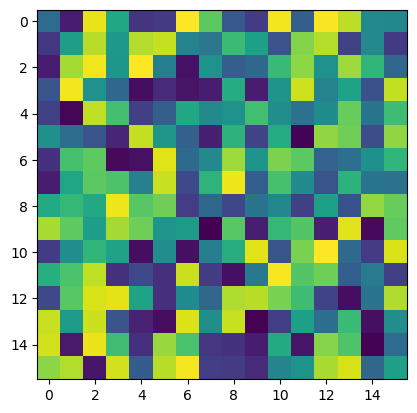

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# This example uses random values
a = np.random.random((16, 16))
plt.imshow(a, interpolation='nearest')
plt.show()


# Desarrollo Taarea

In [5]:
import time
import pandas as pd


## Reproducibilidad | Algoritmo Genético Estocástico

AG:
- Un algoritmo genético es estocástico
- Usa aleatoriedad en selección, cruce y mutación
- La aleatoriedad mejora la exploración y la robustez
- Resultados pueden variar entre ejecuciones

In [6]:
BASE_SEED = 42
random.seed(BASE_SEED)


**notas**
- Se define semilla con valor 42 y se ejecuta una vez: random.seed(SEED)
- El generador de números aleatorios (pseudo) empieza siempre desde el mismo estado inicial
  - A partir de acá, cada llamada a rand() consume el siguiente número de la secuencia pseudoaleatoria
  - Esto para que en cada generación, los valores aleatorios sean distintos, pero deterministas. -> **Variabilidad estocástica real del algoritmo** (que el resultado no dependa de la "suerte”)
  - **Estrategia**: Cambiar la semilla en cada corrida, pero de forma determinística

## Funciones

### Función Ejecución Algoritmo Genético

In [7]:
def run_ga(
        pop_size: int, 
        mutation_rate: float,
        fitness_function,
        individual_factory,
        termination_condition,
        gene_factory,
        number_of_genes: int, 
        seed: int,
        silent: bool = True,
        max_iter: int = 100
    ):

    # reproducibilidad
    random.seed(seed)
    np.random.seed(seed)

    # medir el tiempo de CPU
    start_time = time.process_time() 

    ga = GA(
        pop_size=pop_size,
        mutation_rate=mutation_rate,
        fitness=fitness_function,
        individual_factory=individual_factory,
        termination_condition=termination_condition,
        gene_factory=gene_factory,
        max_iter=max_iter,
        silent=silent
    )

    best_fitness_list, worst_fitness_list, avg_list, best_individual, best_individuals = ga.run()

    end_time = time.process_time()
    execution_time = end_time - start_time

    # métricas de la corrida
    generations = len(best_fitness_list)
    converged = (generations > 0) and (best_fitness_list[-1] == number_of_genes)

    best_last = float(best_fitness_list[-1]) if generations > 0 else float("nan")
    worst_last = float(worst_fitness_list[-1]) if len(worst_fitness_list) > 0 else float("nan")
    avg_last = float(avg_list[-1]) if len(avg_list) > 0 else float("nan")

    return {
        "pop_size": pop_size,
        "mutation_rate": mutation_rate,
        "converged": converged,
        "generations": generations,
        "best_fitness": best_last,
        "worst_fitness": worst_last,
        "avg_fitness": avg_last,
        "best_fitness_list": list(best_fitness_list),
        "worst_fitness_list": list(worst_fitness_list),
        "avg_fitness_list": list(avg_list),
        "best_individual": best_individual,
        "execution_time": execution_time,
        "best_individuals": best_individuals
    }


### Función Ejecución de Experimentos

In [8]:
generaciones_titulo = "Generaciones promedio para converger"
tasa_exito_titulo = "Tasa de éxito"
tiempo_ejecucion_titulo = "Tiempo de ejecución promedio (segundos)"

def ejecutar_experimentos(
        pop_sizes, 
        mutation_rates, 
        fitness_function,
        individual_factory,
        gene_factory,
        termination_condition,
        number_of_genes, 
        max_iter, 
        n_repetitions,
        target,
        silent=True,
    ):

    print("[INFO] parámetros de experimentos")
    print(f" - tamaños de población: {pop_sizes}")
    print(f" - tasas de mutación: {mutation_rates}")
    print(f" - secuencia a encontrar: {target}")
    print(f" - número de genes: {number_of_genes}")
    print(f" - max_iter por corrida: {max_iter}")
    print(f" - repeticiones por celda: {n_repetitions}")
    print(f" - número total de corridas: {len(mutation_rates) * len(pop_sizes) * n_repetitions}")


    out_generaciones_converger= np.full((len(mutation_rates), len(pop_sizes)), np.nan, dtype=float)
    out_tasas_exito = np.zeros((len(mutation_rates), len(pop_sizes)), dtype=float)
    out_tiempos_ejecucion = np.zeros((len(mutation_rates), len(pop_sizes)), dtype=float)
    out_resultados = np.full((len(mutation_rates), len(pop_sizes)), None)

    # iteración sobre tasas de mutación
    for i, mr in enumerate(mutation_rates):

        # iteración sobre tamaños de población
        for j, ps in enumerate(pop_sizes):

            generations_to_converge = []
            resultados = []

            total_time = 0.0
            for k in range(n_repetitions):
                
                # semilla única y reproducible por combinación de parámetros y corrida
                seed = BASE_SEED + (i * 10_000) + (j * 100) + k
                result = run_ga(
                    pop_size=ps,
                    mutation_rate=mr,
                    fitness_function=fitness_function,
                    individual_factory=individual_factory,
                    termination_condition=termination_condition,
                    gene_factory=gene_factory,
                    number_of_genes=number_of_genes,
                    seed=seed,
                    max_iter=max_iter,
                    silent=silent
                )

                resultados.append(result)

                # solo considerar corridas que convergen
                if result["converged"]:
                    generations_to_converge.append(result["generations"])
                else:
                    generations_to_converge.append(np.nan)

                total_time += result["execution_time"]

            # en el caso que ninguna corrida convergió, se marca como NaN
            valid = np.array(generations_to_converge)
            valid = valid[~np.isnan(valid)]

            # tasa de éxito: proporción de corridas que convergieron
            out_tasas_exito[i, j] = len(valid) / n_repetitions
            out_tiempos_ejecucion[i, j] = total_time / n_repetitions

            # promedio de generaciones para converger (solo si hubo al menos un éxito)
            if len(valid) == 0:
                out_generaciones_converger[i, j] = np.nan
            else:
                out_generaciones_converger[i, j] = valid.mean()
            
            out_resultados[i, j] =  resultados

    return out_generaciones_converger, out_tasas_exito, out_tiempos_ejecucion, out_resultados


### Función Graficar Heatmap GA

In [9]:
def graficar_heatmap_ga(datos, titulo, pop_sizes, mutation_rates, cmap):
    # tamaño de la figura
    cell_width = 0.8   # pulgadas por columna
    cell_height = 0.6  # pulgadas por fila

    fig_width = max(8, cell_width * len(pop_sizes))
    fig_height = max(4, cell_height * len(mutation_rates))

    plt.figure(figsize=(fig_width, fig_height))

    # Heatmap
    im = plt.imshow(datos, interpolation="nearest", aspect="auto", cmap=cmap)

    plt.title(
        f"GA: {titulo}\n"
        "(Tamaño Población vs Tasa de Mutación)"
    )
    plt.xlabel("Tamaño Población")
    plt.ylabel("Tasa de Mutación")

    plt.xticks(
        ticks=np.arange(len(pop_sizes)),
        labels=pop_sizes
    )
    plt.yticks(
        ticks=np.arange(len(mutation_rates)),
        labels=mutation_rates
    )

    # mapa de colores
    cbar = plt.colorbar(im)
    cbar.set_label(f"{titulo}")

    plt.tight_layout()
    plt.show()
    

### Imprimir Resultados Experimentos

In [10]:
def imprimir_resultados(resultados, target):
    print("[INFO] Resultados:")
    for i, fila in enumerate(resultados):
        for j, res_list in enumerate(fila):
            for k, res in enumerate(res_list):
                print(f"[Info] Ejecución ({i},{j}) | run: {k} | = pop_size={res['pop_size']}, mutation_rate={res['mutation_rate']}")
                for gen, (fit, indiv) in enumerate(zip(res["best_fitness_list"],
                                                    res["best_individuals"]), 1):
                    print(f"  Generación {gen}: best={fit} indiv={''.join(indiv)}")
                print(f"  Individuo final: {''.join(res['best_individual'])}\n")


## Ejercicio 1: Hotmap Tamaño Población vs Tasa de Mutación

**EXERCISE**: Build a hotmap by varying the mutation rate and the population size of the bit sequence example. What can you comment on the hotmap? What are the informal conclusion you can draw from it?

In [11]:
#  _    _       _
# | |  | |     | |
# | |__| | ___ | |_ _ __ ___   __ _ _ __
# |  __  |/ _ \| __| '_ ` _ \ / _` | '_ \
# | |  | | (_) | |_| | | | | | (_| | |_) |
# |_|  |_|\___/ \__|_| |_| |_|\__,_| .__/
#                                  | |
#                                  |_|
#
# WRITE YOUR ANSWER HERE

#**test**: se testea función usando configuración del enunciado.

result = run_ga(
    pop_size=100,
    mutation_rate=0.1,
    fitness_function=fitness_bits,
    individual_factory=sequence_bit_factory,
    gene_factory=gene_factory,
    termination_condition = lambda f : f == NUMBER_OF_GENES,
    number_of_genes=NUMBER_OF_GENES,
    seed=BASE_SEED,
    silent=False
)
print(best_fitness_list)



iter 0 of 100
best is: ['1', '0', '0', '0', '1', '0', '0', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '1', '0']
with: 15 worst: 5 acc. Avg: 9.71
iter 1 of 100
best is: ['1', '0', '0', '0', '1', '0', '0', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1']
with: 17 worst: 8 acc. Avg: 11.8
iter 2 of 100
best is: ['1', '0', '0', '0', '0', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1']
with: 17 worst: 9 acc. Avg: 13.49
iter 3 of 100
best is: ['1', '0', '1', '0', '1', '0', '0', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1']
with: 18 worst: 12 acc. Avg: 15.29
best found is: ['1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1', '0', '1']
with: 19 worst: 14 acc. Avg: 16.66
[15, 17, 17, 18, 19]


**notas**:
- la función entrega mismo resultado que el enunciado

### Configuración | Hyperparámetros

In [12]:
P1_NUMBER_OF_GENES = len(SEQUENCE_OF_BITS_TO_FIND)

# eje X (horizontal)
# tasas de mutación (% de cambio en genes cuando se genera un nuevo individuo)
#MUTATION_RATES = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 0.8]
#MUTATION_RATES = [0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3]
#MUTATION_RATES = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]
P1_MUTATION_RATES = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.5, 0.8]

# eje Y (vertical)
# cantidad de individuos a considerar en cada experimento 
#POP_SIZES = [5, 10, 50, 100, 150, 200, 350, 500]  
#POP_SIZES = [10, 25, 50, 75, 100, 150]
#POP_SIZES = [2, 5, 10, 20, 40, 80, 120]
P1_POP_SIZES = [2, 5, 10, 15, 20, 30, 50, 70, 90, 100, 300, 500, 800]

# límite de generaciones por corrida
P1_MAX_ITER = 100

# número de repeticiones para promediar el resultado por cada combinación de parámetros (reduce varianza)
P1_N_REPETITIONS = 10


**notas**
1. **Rango de Tamaños de Población** (`POP_SIZES`)
    Se eligieron estos valores para observar el efecto de la diversidad y el tamaño de muestreo de la población en la convergencia:
   - **Poblaciones Pequeñas** (2, 30):
     - Sirven para simular un escenario donde la diversidad es muy baja.
     - Una población muy pequeña puede converger rápidamente a un sub-óptimo local (convergencia prematura) porque no tiene suficientes candidatos para explorar el espacio de búsqueda.
   - **Población Moderada** (>50):
     - valor inicial estándar para problemas "tipo"" de AG. 
     - Se busca buena mezcla de exploración y explotación.
   - **Poblaciones Grandes** (>100):
     - Alta diversidad y cubren mejor el espacio de búsqueda (más exploración).
     - Permiten ver si el aumento en la diversidad compensa el costo computacional de tener más individuos en cada generación.

2. **Rango de Tasas de Mutación** (`MUTATION_RATES`)
    La tasa de mutación controla el equilibrio entre explotación (usar las mejores soluciones encontradas) y exploración (introducir novedades). Los valores cubren desde una mutación casi nula hasta una mutación dominante:
    - **Tasa de Mutación Muy Baja** (<0,1):
      - Simula un AG que se basa casi exclusivamente en el cruce (explotación).
      - Esto puede llevar a la pérdida de diversidad rápidamente y al estancamiento en un óptimo local.
    - **Tasa de Mutación Estándar** (<0.25):
      - Valores típicos para AG. 
      - Busca un equilibrio entre mantener la estabilidad de los buenos individuos y permitir una exploración suficiente para escapar de óptimos locales.
    - **Tasa de Mutación Alta** (>0,3):
      - Simula un algoritmo que prioriza la exploración aleatoria.
      - Una tasa tan alta tiende a destruir la estructura de los individuos aptos (*fitness* alto) generados por el cruce, haciendo que el AG se comporte de forma muy similar a una búsqueda puramente aleatoria y reduciendo su eficiencia.

### Iteraciones Sobre Combinaciones de Parámetros

In [13]:
p1_generaciones, p1_exito, p1_rendimiento, p1_resultados = ejecutar_experimentos(
    pop_sizes=P1_POP_SIZES, 
    mutation_rates=P1_MUTATION_RATES,
    fitness_function=fitness_bits,
    individual_factory=sequence_bit_factory,
    gene_factory=gene_factory,
    termination_condition=lambda f: f == P1_NUMBER_OF_GENES,
    number_of_genes=P1_NUMBER_OF_GENES, 
    max_iter=P1_MAX_ITER, 
    n_repetitions=P1_N_REPETITIONS,
    target=SEQUENCE_OF_BITS_TO_FIND,
    silent=True
    )
print(f"[INFO] ejecución terminada: {len(p1_resultados)} celdas en resultados")


[INFO] parámetros de experimentos
 - tamaños de población: [2, 5, 10, 15, 20, 30, 50, 70, 90, 100, 300, 500, 800]
 - tasas de mutación: [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.5, 0.8]
 - secuencia a encontrar: 1010101010101010101
 - número de genes: 19
 - max_iter por corrida: 100
 - repeticiones por celda: 10
 - número total de corridas: 1820
[INFO] ejecución terminada: 14 celdas en resultados


### Heatmap | Promedio Generaciones para Converger

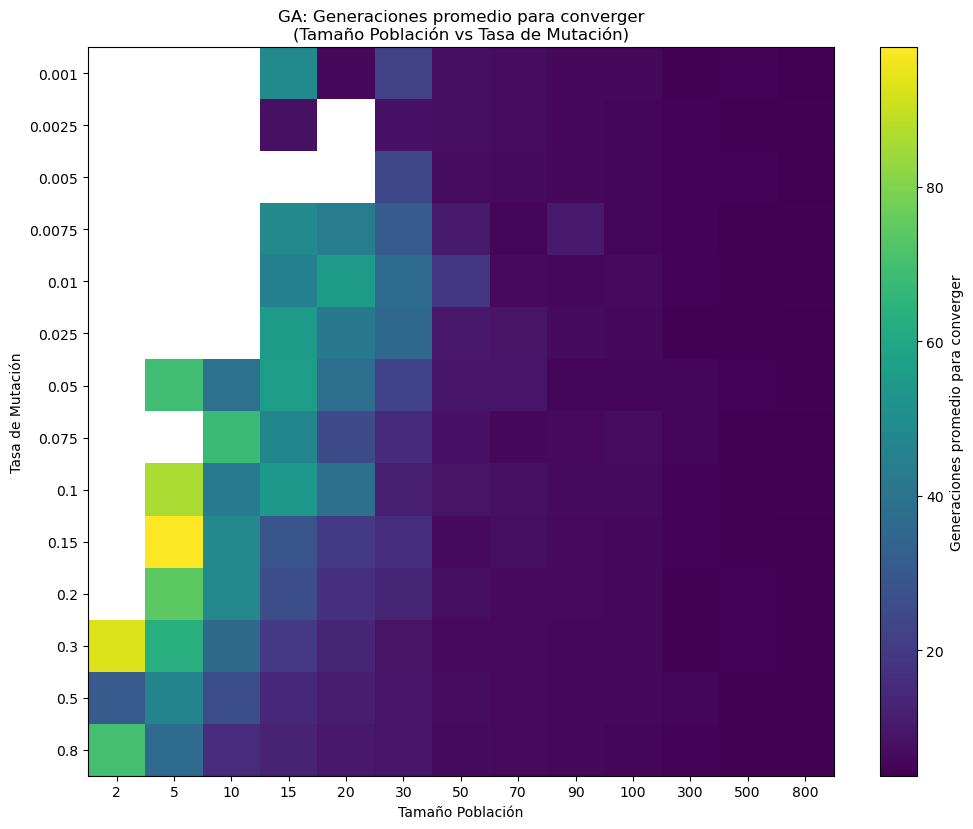

In [14]:
graficar_heatmap_ga(p1_generaciones, generaciones_titulo, P1_POP_SIZES, P1_MUTATION_RATES, cmap="viridis")


**notas**
- Este gráfico mide la **robustez** del Algoritmo Genético (AG), mostrando el porcentaje de veces (en las repeticiones) que el AG encontró la solución óptima (fitness=19) antes de las 100 iteraciones.
- **Vulnerabilidad a Baja Diversidad y Mutación:** La  única región de no convergencia (celdas blancas) se encuentra en la esquina superior izquierda, donde la **Población es muy pequeña (<10)** y la **Tasa de Mutación es muy baja (<0.01$)**. Esto sugiere estancamiento por falta de exploración/diversidad dentro del límite de `MAX_ITER=100`.
- A partir de tamaños de población **moderados-altos** (≈ 50–100 en adelante), el GA tiende a converger en **pocas generaciones** (zonas oscuras), mostrando que el aumento de diversidad inicial y la presión selectiva ayudan a alcanzar el óptimo rápidamente.
- Con **poblaciones muy pequeñas**, aumentar la mutación mejora la exploración (reduce NaN), pero si la mutación es excesiva puede aumentar la cantidad de generaciones necesarias (comportamiento más cercano a búsqueda aleatoria).
- En conclusión, la convergencia está dominada por el **tamaño de población** (diversidad) y por evitar tasas de mutación demasiado bajas.

### Heatmap | Tasa de Éxito

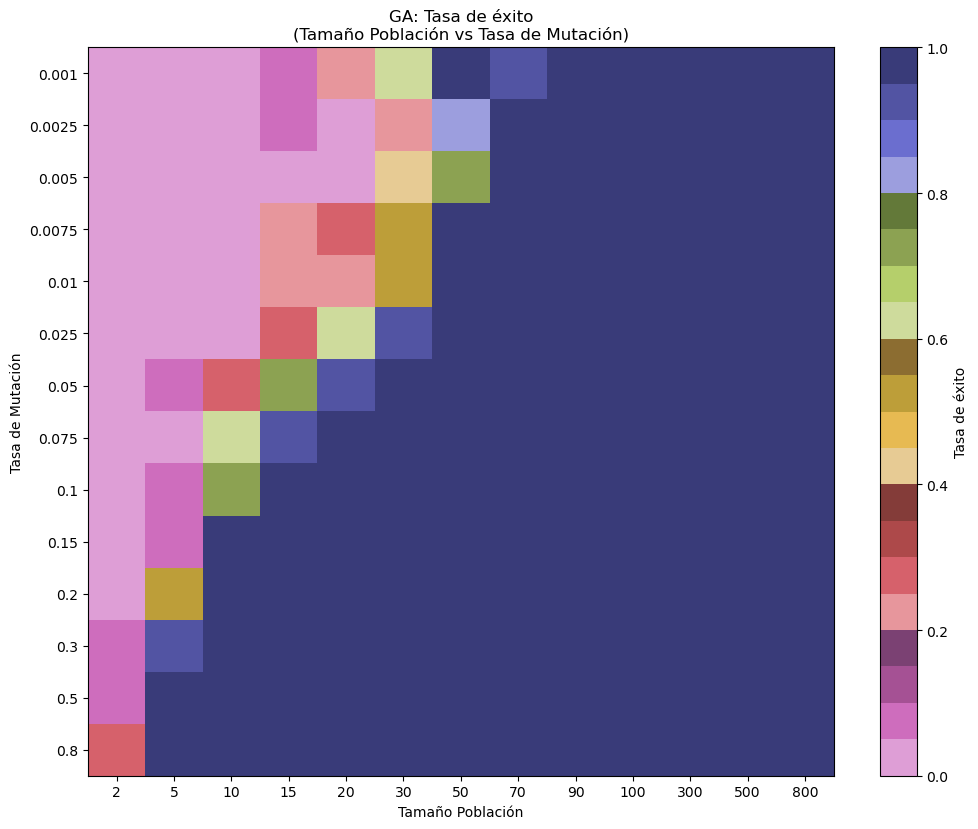

In [15]:
graficar_heatmap_ga(p1_exito, tasa_exito_titulo, P1_POP_SIZES, P1_MUTATION_RATES, cmap="tab20b_r")


**notas**
- Para tamaños de población **altos** (≈ 70/90/100 en adelante), la **tasa de éxito es cercana a 1** en prácticamente todas las tasas de mutación evaluadas. Esto indica alta robustez del algoritmo cuando existe suficiente diversidad.
- Para tamaños de población **pequeños** (≈ 2–20), la tasa de éxito cae fuertemente, especialmente con **mutación baja** (≈ 0.001–0.01), consistente con estancamiento en óptimos subóptimos y falta de exploración.
- Con mutación **muy alta** (≈ 0.5–0.8), la tasa de éxito puede recuperarse parcialmente en poblaciones pequeñas, pero no necesariamente alcanza el desempeño de poblaciones grandes: la mutación alta ayuda a explorar, pero también puede destruir “buenas” estructuras.
- En conclusión, para este problema, el factor crítico para el éxito es el **tamaño de la población**, la mutación actúa como mecanismo correctivo cuando la población es pequeña, pero no reemplaza la diversidad que entrega un `POP_SIZE` mayor.

### Heatmap | Tiempos de Ejecución

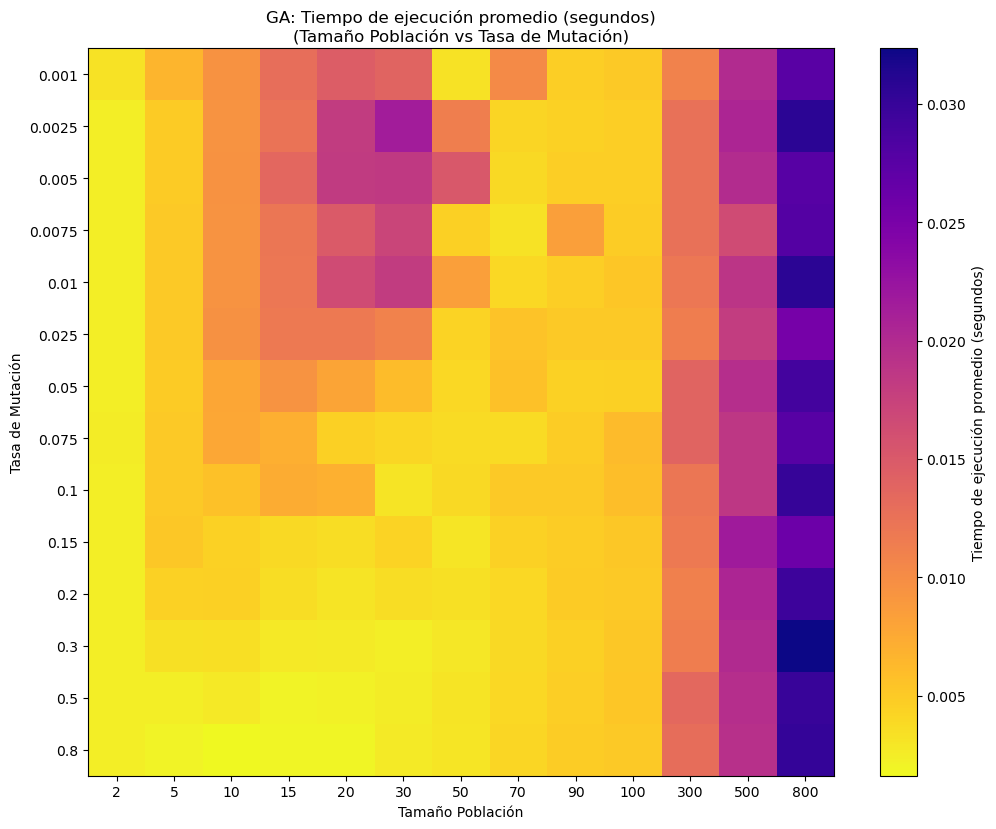

In [16]:
graficar_heatmap_ga(p1_rendimiento, tiempo_ejecucion_titulo, P1_POP_SIZES, P1_MUTATION_RATES, cmap="plasma_r")


**notas**:
- El tiempo de ejecución crece principalmente con el **tamaño de población**: al aumentar `POP_SIZE`, cada generación evalúa más individuos y el costo por iteración crece.
- La **tasa de mutación** tiene un impacto secundario comparado con `POP_SIZE`. Su efecto se manifiesta indirectamente: combinaciones que tardan más en converger (o no convergen) tienden a consumir más tiempo.
- Para poblaciones muy grandes (≈ 500–800), el tiempo aumenta de forma clara aunque el número de generaciones sea bajo, lo cual refleja que el costo por generación domina.
- En conclusión, existe un trade-off explícito: `POP_SIZE` grande mejora éxito y reduce generaciones, pero aumenta el costo computacional por iteración.

**conclusiones**:
- Los heatmaps muestran en conjunto que el tamaño de la población es el principal factor que determina la calidad de la convergencia en esta configuración del GA:
  - pasar de poblaciones muy pequeñas (≈ 2–20) a poblaciones medianas o grandes (≈ 50–100 o más) incrementa drásticamente la tasa de éxito y reduce el número de generaciones necesarias.
- Tasas de mutación muy bajas combinadas con poblaciones pequeñas conducen a convergencia prematura o estancamiento:
  - el algoritmo frecuentemente no alcanza el óptimo dentro del número máximo de generaciones (región NaN en el heatmap de convergencia).
    - La tasa de mutación cumple un rol secundario pero importante de balance:
      - demasiado baja -> exploración insuficiente (falla en converger),
      - moderada (≈ 0.05–0.2) -> convergencia estable y eficiente cuando la población no es pequeña,
      - demasiado alta (≈ 0.5–0.8) -> mayor aleatoriedad; puede ayudar a la exploración en poblaciones pequeñas, pero reduce la eficiencia.
- El heatmap de tiempo de ejecución destaca un trade-off práctico:
  - poblaciones más grandes mejoran la robustez y la velocidad de convergencia (en generaciones), pero incrementan el costo computacional por generación.
Por lo tanto, una “región buena” informal suele corresponder a tamaños de población medianos a grandes con tasas de mutación moderadas, maximizando el éxito mientras se mantiene el tiempo de ejecución en niveles manejables.


---

## Ejercicio 2: Finding Word

We will now do another exercise,  close to what we have seen during the lecture. 

**EXERCISE**: Use the genetic algorithm to search for the string `helloworld`, in which each gene is a character.

In [17]:
#   ______ _           _ _              __          __           _ 
#  |  ____(_)         | (_)             \ \        / /          | |
#  | |__   _ _ __   __| |_ _ __   __ _   \ \  /\  / /__  _ __ __| |
#  |  __| | | '_ \ / _` | | '_ \ / _` |   \ \/  \/ / _ \| '__/ _` |
#  | |    | | | | | (_| | | | | | (_| |    \  /\  / (_) | | | (_| |
#  |_|    |_|_| |_|\__,_|_|_| |_|\__, |     \/  \/ \___/|_|  \__,_|
#                                 __/ |                            
#                                |___/                             
# WRITE YOUR ANSWER HERE

WORD = "helloworld"
P2_ALPHABET = list(string.ascii_lowercase + " ")
#P2_ALPHABET = "ABCDEFGHIJKLMNOPQRSTUVWXYZ "
P2_NUMBER_OF_GENES = len(WORD)

def p2_fitness_word(individual):
    return sum(1 for a, b in zip(individual, WORD) if a == b)

def p2_gene_factory_word():
    return random.choice(P2_ALPHABET)

def p2_individual_factory_word():
    return [p2_gene_factory_word() for _ in range(P2_NUMBER_OF_GENES)]

print(P2_ALPHABET)


['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', ' ']


### Configuración | Hyperparámetros

In [18]:
# eje X (horizontal): tasa de mutación
P2_MUTATION_RATES = [0.1, 0.2]

# eje Y (vertical): tamaño de población
P2_POP_SIZES = [50, 100, 300]

# límite de generaciones por corrida
P2_MAX_ITER = 100

# número de repeticiones para promediar el resultado por cada combinación de parámetros (reduce varianza)
P2_N_REPETITIONS = 1


**notas**
- para los experimentos se considera las combinaciones de 3 tasa de mutación contra 3 tamaños de población
- se considera un máximo de 100 iteraciones y sin repeticiones

In [19]:
p2_generaciones, p2_exito, p2_rendimiento, p2_resultados = ejecutar_experimentos(
    pop_sizes=P2_POP_SIZES, 
    mutation_rates=P2_MUTATION_RATES,
    fitness_function=p2_fitness_word,
    individual_factory=p2_individual_factory_word,
    gene_factory=p2_gene_factory_word,
    termination_condition=lambda f: f == P2_NUMBER_OF_GENES,
    number_of_genes=P2_NUMBER_OF_GENES, 
    max_iter=P2_MAX_ITER, 
    n_repetitions=P2_N_REPETITIONS,
    target=WORD,
    silent=True
    )
print(f"[INFO] ejecución terminada: {len(p1_resultados)} celdas en resultados")


[INFO] parámetros de experimentos
 - tamaños de población: [50, 100, 300]
 - tasas de mutación: [0.1, 0.2]
 - secuencia a encontrar: helloworld
 - número de genes: 10
 - max_iter por corrida: 100
 - repeticiones por celda: 1
 - número total de corridas: 6
[INFO] ejecución terminada: 14 celdas en resultados


In [20]:
imprimir_resultados(p2_resultados, WORD)


[INFO] Resultados:
[Info] Ejecución (0,0) | run: 0 | = pop_size=50, mutation_rate=0.1
  Generación 1: best=3 indiv=dvnlnaotsd
  Generación 2: best=3 indiv=mdllkasrad
  Generación 3: best=4 indiv=hdllkaotsd
  Generación 4: best=5 indiv=hellcybrld
  Generación 5: best=7 indiv=hellvaorhd
  Generación 6: best=7 indiv=hellcyorld
  Generación 7: best=8 indiv=hellcyorld
  Generación 8: best=8 indiv=hellcyorld
  Generación 9: best=8 indiv=hellcyorld
  Generación 10: best=8 indiv=hellczorld
  Generación 11: best=8 indiv=hellcyorld
  Generación 12: best=8 indiv=hellkaorld
  Generación 13: best=8 indiv=hellcyorld
  Generación 14: best=8 indiv=hellcyorld
  Generación 15: best=8 indiv=hellkaorld
  Generación 16: best=8 indiv=hellkaorld
  Generación 17: best=8 indiv=hellcyorld
  Generación 18: best=8 indiv=hellcyorld
  Generación 19: best=8 indiv=hellcyorld
  Generación 20: best=8 indiv=hellkyorld
  Generación 21: best=8 indiv=hellcyorld
  Generación 22: best=8 indiv=hellcyorld
  Generación 23: best

## Ejercicio 3: Curva Fitness

**EXERCISE**: Plot the evolution of the fitness function across generations

In [21]:
#  ______ _ _                                                   
# |  ____(_) |                                                  
# | |__   _| |_ _ __   ___  ___ ___    ___ _   _ _ ____   _____ 
# |  __| | | __| '_ \ / _ \/ __/ __|  / __| | | | '__\ \ / / _ \
# | |    | | |_| | | |  __/\__ \__ \ | (__| |_| | |   \ V /  __/
# |_|    |_|\__|_| |_|\___||___/___/  \___|\__,_|_|    \_/ \___|
#                                                               
# WRITE YOUR ANSWER HERE

def graficar_curvas_fitness_ga(best_fitness_list, avg_fitness_list, worst_fitness_list, titulo):
    plt.figure(figsize=(10,4))
    plt.plot(best_fitness_list, label=f"mejor", color="green")
    plt.plot(avg_fitness_list, label=f"promedio", color="grey")
    plt.plot(worst_fitness_list, label=f"peor", color="red")
    plt.xlabel("Generaciones")
    plt.ylabel("Fitness")
    plt.title(
        f"Curva de Fitness\n"
        f"Experimento: {titulo}"
    )
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


**notas**
- se implementa ciclo para recorrer resultados, cuyas iteraciones están agrupadas por tamaño de población y tasa de mutación
- este ciclo permite visualizar la curva fitness para cada experimento
- la **curva fitness** implementada corresponde a la evolución por generación de:
  - Best fitness: máximo fitness dentro de la población en cada generación.
  - Average fitness: promedio del fitness de toda la población.
  - Worst fitness: mínimo fitness dentro de la población.
- Se tuvo que modificar la clase AG para incluir el retorno de la lista de peores resultados de la f*unción fitness*

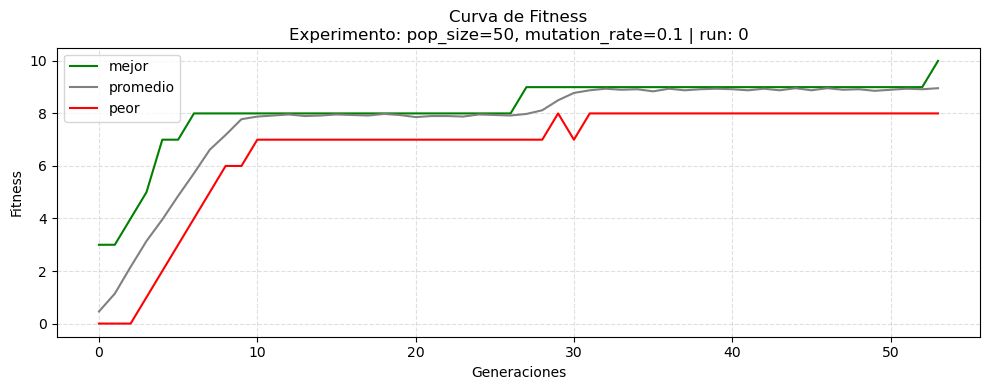

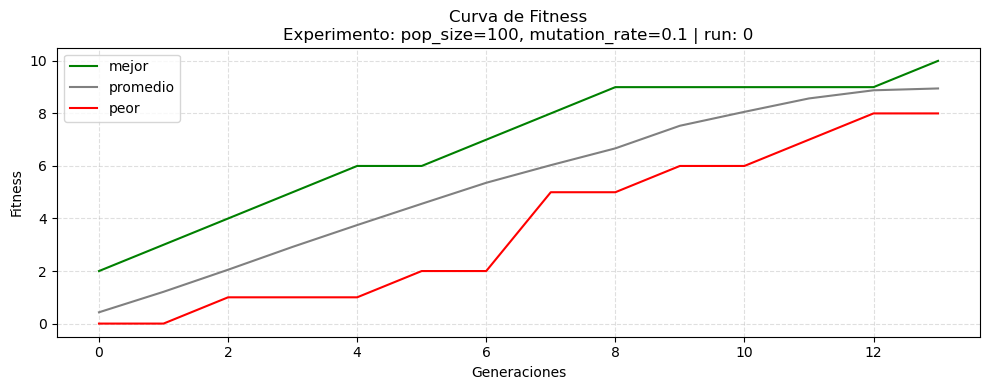

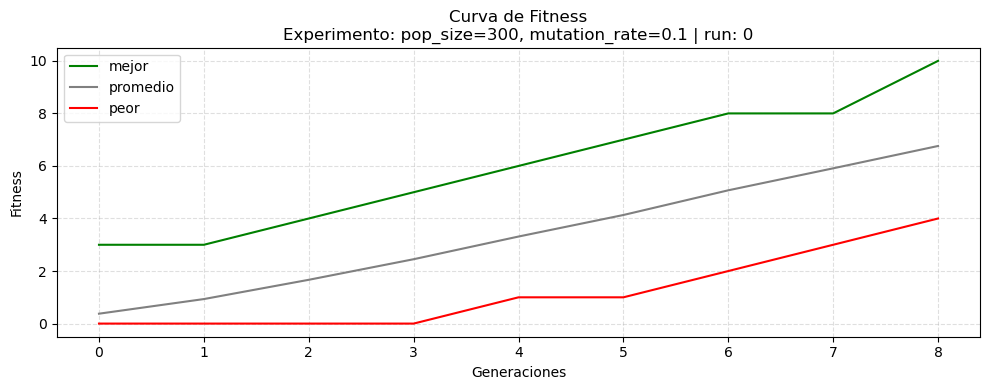

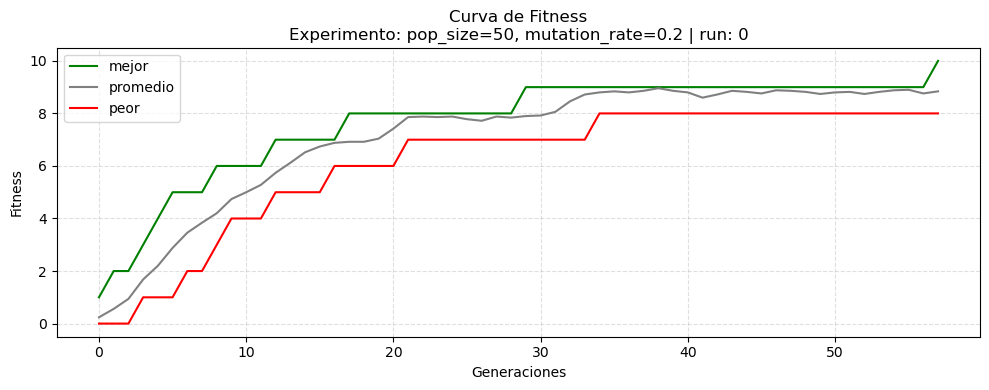

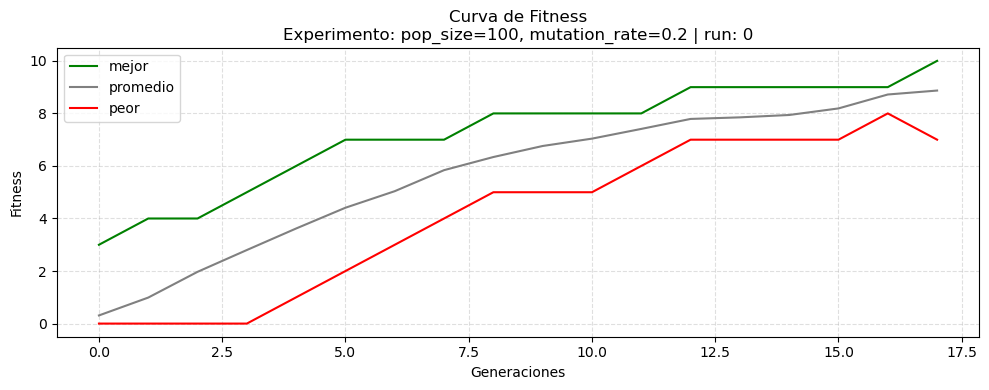

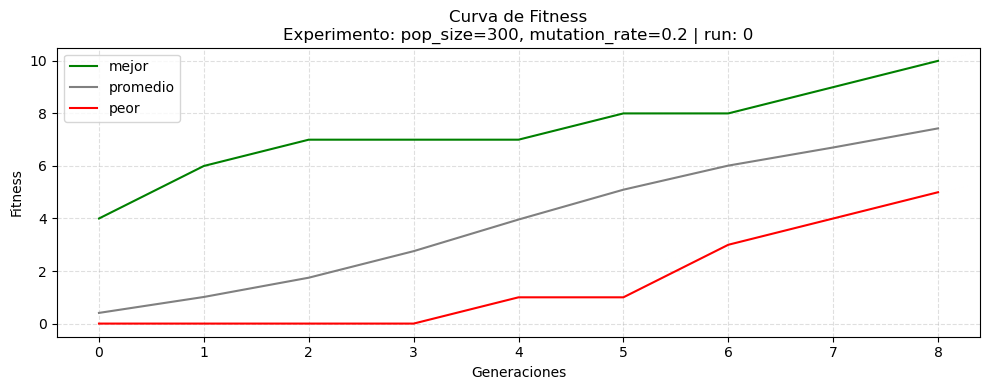

In [22]:
for i, fila in enumerate(p2_resultados):
    for j, res_list in enumerate(fila):
        for k, res in enumerate(res_list):
            graficar_curvas_fitness_ga(
                best_fitness_list=res["best_fitness_list"],
                avg_fitness_list=res["avg_fitness_list"],
                worst_fitness_list=res["worst_fitness_list"],
                titulo=f"pop_size={res['pop_size']}, mutation_rate={res['mutation_rate']} | run: {k}"
            )


**notas y conclusiones**:
- La curva de best fitness evidencia el progreso del algoritmo: 
  - subidas rápidas al inicio muestran que la selección por torneo amplifica individuos relativamente buenos y el crossover permite recombinar aciertos parciales.  ￼
- El acercamiento del average fitness al best fitness es un indicador de convergencia: 
  - cuando las curvas se pegan, la población se homogeneiza (menor diversidad), lo que reduce la probabilidad de mejoras futuras sin mutación suficiente.
- Los plateaus prolongados sugieren falta de exploración: 
  - típicamente por tasa de mutación demasiado baja o por poblaciones pequeñas que pierden diversidad rápidamente.
- Las caídas del best fitness son esperables sin elitismo: 
  - al reemplazar toda la población por descendencia, el mejor individuo puede perderse; por ello, la curva no está obligada a ser monótona.  ￼
  - El análisis debe hacerse por tendencias, no por una sola corrida: como el GA es estocástico (selección aleatoria + mutación), se recomienda describir patrones comunes (subida inicial, meseta, variabilidad) y, si es posible, resumir varias corridas (promedio y dispersión).


**resumen**:

| pop_size | mutation_rate | Observaciones principales | Interpretación |
|----------|---------------|---------------------------|----------------|
| 50 | 0.1 | Convergencia muy rápida del best fitness en las primeras generaciones, seguida de un plateau prolongado. El fitness promedio se acerca tempranamente al mejor. | Alta explotación inicial pero pérdida temprana de diversidad. Evidencia de convergencia prematura típica de poblaciones pequeñas. |
| 100 | 0.1 | Incremento progresivo y estable del best fitness. El promedio crece de forma sostenida manteniendo cierta separación respecto al mejor. | Buen equilibrio entre exploración y explotación. Configuración eficiente que alcanza el óptimo sin estancarse temprano. |
| 300 | 0.1 | Mejora más lenta al inicio, pero convergencia rápida al óptimo en pocas generaciones. Se mantiene una brecha clara entre best y average fitness. | Alta diversidad poblacional permite exploración robusta y reduce riesgo de óptimos locales. Mayor costo computacional por generación. |
| 50 | 0.2 | Convergencia algo más lenta que con mutation_rate=0.1, con curvas más suaves. El worst fitness mejora gradualmente. | Mayor mutación ayuda a mantener diversidad, pero no evita completamente el estancamiento en poblaciones pequeñas. |
| 100 | 0.2 | Evolución estable del best y average fitness, con ligeras oscilaciones. El peor fitness mejora de forma consistente. | Mutación más alta favorece exploración sin degradar significativamente la convergencia. Configuración balanceada. |
| 300 | 0.2 | Convergencia robusta y rápida, manteniendo alta diversidad durante las primeras generaciones. El average fitness crece de forma casi lineal. | Combinación más robusta: maximiza exploración y alcanza el óptimo de manera confiable, aunque con mayor costo computacional. |

---

## Ejercicio 4: Problema de la Mochila

The knapsack problem is a well-known problem in combinatorial optimization. It can be summarized as follows: given a set of items, each having a value and a weight, determine the number of each item to include in a collection, such that (i) the total weight is less or equal a given limit and (ii) the total value is as large as possible.

![texto alternativo](https://upload.wikimedia.org/wikipedia/commons/thumb/f/fd/Knapsack.svg/250px-Knapsack.svg.png)

[Description and example of the Knapsack problem](https://en.wikipedia.org/wiki/Knapsack_problem)

In this exercise, we will consider only the _unbounded knapsack problem_ variant of the problem.

**EXERCISE**: Use the Genetic Algorithm to solve the Knapsack Problem described in the Wikipedia page

In [23]:
#  _    _       _       _                                     _    
# | |  | |     | |     | |                                   | |   
# | |  | |_ __ | |__   | | ___ __   __ _ _ __  ___  __ _  ___| | __
# | |  | | '_ \| '_ \  | |/ / '_ \ / _` | '_ \/ __|/ _` |/ __| |/ /
# | |__| | | | | |_) | |   <| | | | (_| | |_) \__ \ (_| | (__|   < 
#  \____/|_| |_|_.__/  |_|\_\_| |_|\__,_| .__/|___/\__,_|\___|_|\_\
#                                       | |                        
#                                       |_|                        
# WRITE YOUR ANSWER HERE


# Definición del Problema (Datos de Wikipedia)
# Cada ítem es una tupla o diccionario con su Peso (w) y Valor (v)
# Capacidad Máxima de la mochila: 15 kg


![Problema de la Mochila](images/wikipedia_snapsack_problem_illustration.png)

**objetos**: (libros)
| color | peso | valor |
|-------|------|-------|
| verde | 12 | 4 |
| gris | 1 | 2 |
| amarillo | 4 | 10 |
| naranja | 1 | 1 |
| azul | 2 | 2 |


In [24]:
P4_ITEMS = [
    {"color": "Verde", "peso": 12, "valor": 4},
    {"color": "Gris", "peso": 1, "valor": 2},
    {"color": "amarillo", "peso": 4, "valor": 10},
    {"color": "Naranja", "peso": 1, "valor": 1},
    {"color": "Azul", "peso": 2, "valor": 2}
]

P4_MAX_WEIGHT = 15
P4_NUMBER_OF_GENES = len(P4_ITEMS)
P4_MAX_COUNT = [P4_MAX_WEIGHT // item["peso"] if item["peso"] > 0 else 0 for item in P4_ITEMS]

print(P4_MAX_COUNT)

def p4_gene_factory_knapsack(idx=None):
    # si no viene índice, se elige uno al azar
    if idx is None:
        idx = random.randrange(P4_NUMBER_OF_GENES)
    return random.randint(0, P4_MAX_COUNT[idx])

def p4_individual_factory_knapsack():
    # un individuo es una lista de cantidades para cada uno de los k libros
    return [p4_gene_factory_knapsack(i) for i in range(P4_NUMBER_OF_GENES)]

def p4_fitness_knapsack(individual):
    total_peso = sum(qty * item["peso"] for qty, item in zip(individual, P4_ITEMS))
    if total_peso > P4_MAX_WEIGHT:
        #return 0  # penalización
        over_ratio = (total_peso - P4_MAX_WEIGHT) / P4_MAX_WEIGHT
        total_valor = sum(qty * item["valor"] for qty, item in zip(individual, P4_ITEMS))
        penalizacion = over_ratio * total_valor 
        return max(0, total_valor - penalizacion)
    return sum(qty * item["valor"] for qty, item in zip(individual, P4_ITEMS))


[1, 15, 3, 15, 7]


### Configuración | Hyperparámetros

In [25]:
# eje X (horizontal): tasa de mutación
P4_MUTATION_RATES = [0.1, 0.2]

# eje Y (vertical): tamaño de población
P4_POP_SIZES = [50, 100, 500, 1000]

# límite de generaciones por corrida
P4_MAX_ITER = 100

# número de repeticiones para promediar el resultado por cada combinación de parámetros (reduce varianza)
P4_N_REPETITIONS = 5


**notas**
- para la evaluación de la implementación del algoritmo de la mochila, se sigue extrategia de experimentos: 
  - 2 combinaciones de tasa de mutación
  - 4 combinaciones de tamaños de población
  - 100 interaciones máximas (este dato es relevante para esta implementación, ya que es la condición de corte del experimento)
  - 5 repeticiones por experimentos para evaluar mejoras en los resultados

In [26]:
p4_generaciones, p4_exito, p4_rendimiento, p4_resultados = ejecutar_experimentos(
    pop_sizes=P4_POP_SIZES, 
    mutation_rates=P4_MUTATION_RATES,
    fitness_function=p4_fitness_knapsack,
    individual_factory=p4_individual_factory_knapsack,
    gene_factory=p4_gene_factory_knapsack,
    termination_condition=lambda f: False,
    number_of_genes=P4_NUMBER_OF_GENES, 
    max_iter=P4_MAX_ITER, 
    n_repetitions=P4_N_REPETITIONS,
    target=P4_ITEMS,
    silent=True
    )
print(f"[INFO] ejecución terminada: {len(p4_resultados)} celdas en resultados")


[INFO] parámetros de experimentos
 - tamaños de población: [50, 100, 500, 1000]
 - tasas de mutación: [0.1, 0.2]
 - secuencia a encontrar: [{'color': 'Verde', 'peso': 12, 'valor': 4}, {'color': 'Gris', 'peso': 1, 'valor': 2}, {'color': 'amarillo', 'peso': 4, 'valor': 10}, {'color': 'Naranja', 'peso': 1, 'valor': 1}, {'color': 'Azul', 'peso': 2, 'valor': 2}]
 - número de genes: 5
 - max_iter por corrida: 100
 - repeticiones por celda: 5
 - número total de corridas: 40
[INFO] ejecución terminada: 2 celdas en resultados


### Función Visualización Algoritmo Mochila

In [27]:
def imprimir_resultados_mochila(resultados, items, max_weight):
    print("[INFO] Resultados Detallados de la Mochila:")
    
    all_summaries = []

    # iterar a través de la matriz de resultados
    for i, fila in enumerate(resultados):
        for j, res_list in enumerate(fila):
            for k, res in enumerate(res_list):
                
                # calcular el peso final y decodificar la solución final
                final_individual = res['best_individual']
                total_peso = sum(qty * item["peso"] for qty, item in zip(final_individual, items))
                final_fitness = res["best_fitness_list"][-1]

                status = "OK" if total_peso <= max_weight else "excede capacidad"
                
                # crear la fila de resumen
                summary_row = {
                    "i": i,
                    "j": j,
                    "repeticion": k,
                    "tamano_poblacion": res['pop_size'],
                    "tasa_mutacion": f"{res['mutation_rate']:.2f}",
                    "iteraciones": len(res["best_fitness_list"]),
                    "mejor_fitness": f"${final_fitness:.2f}",
                    "peso_final": f"{total_peso}/{max_weight}",
                    "status": status
                }
                all_summaries.append(summary_row)
                
                # detalles de la Mejor Solución Final
                print("\n[INFO] Detalles de la Mejor Solución Final:")
                print(f" - Ejecución ({i}, {j}, {k}) | Pop={res['pop_size']}, Mut={res['mutation_rate']:.2f} | Fitness Final: ${final_fitness:.2f}")

                
                print(f" - Peso Final: {total_peso}/{max_weight} kg ({status})")

                
                print(" - Contenido de la Mochila (Ítem: Cantidad):")
                
                detalle_solucion = []
                for idx, qty in enumerate(final_individual):
                    if qty > 0:
                        item = items[idx]
                        detalle_solucion.append({
                            "Ítem": item['color'],
                            "Cantidad": qty,
                            "Peso Acumulado (kg)": item['peso'] * qty,
                            "Valor Acumulado ($)": item['valor'] * qty
                        })
                        
                # imprimir la tabla de detalle
                if detalle_solucion:
                    df_detalle = pd.DataFrame(detalle_solucion)
                    print(df_detalle.to_string(index=False))
                else:
                    print("  - Mochila vacía.")
                
    return all_summaries



In [28]:
p4_resumen = imprimir_resultados_mochila(p4_resultados, P4_ITEMS, P4_MAX_WEIGHT)


[INFO] Resultados Detallados de la Mochila:

[INFO] Detalles de la Mejor Solución Final:
 - Ejecución (0, 0, 0) | Pop=50, Mut=0.10 | Fitness Final: $35.00
 - Peso Final: 15/15 kg (OK)
 - Contenido de la Mochila (Ítem: Cantidad):
    Ítem  Cantidad  Peso Acumulado (kg)  Valor Acumulado ($)
    Gris         2                    2                    4
amarillo         3                   12                   30
 Naranja         1                    1                    1

[INFO] Detalles de la Mejor Solución Final:
 - Ejecución (0, 0, 1) | Pop=50, Mut=0.10 | Fitness Final: $36.00
 - Peso Final: 15/15 kg (OK)
 - Contenido de la Mochila (Ítem: Cantidad):
    Ítem  Cantidad  Peso Acumulado (kg)  Valor Acumulado ($)
    Gris         3                    3                    6
amarillo         3                   12                   30

[INFO] Detalles de la Mejor Solución Final:
 - Ejecución (0, 0, 2) | Pop=50, Mut=0.10 | Fitness Final: $34.00
 - Peso Final: 15/15 kg (OK)
 - Contenido de la 

**notas**:

| Mutación | Población | Run | Fitness final ($) | Peso final (kg) | Cumple capacidad | Contenido (ítem:cant) | Detalle peso/valor por ítem (kg,$) |
|---:|---:|---:|---:|---:|:---:|---|---|
| 0.10 | 50 | 0 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 50 | 1 | 35 | 15/15 | Sí | Gris:2, amarillo:3, Naranja:1 | Gris (2,4); amarillo (12,30); Naranja (1,1) |
| 0.10 | 50 | 2 | 32 | 15/15 | Sí | Gris:5, amarillo:2, Azul:1 | Gris (5,10); amarillo (8,20); Azul (2,2) |
| 0.10 | 50 | 3 | 33 | 15/15 | Sí | amarillo:3, Naranja:3 | amarillo (12,30); Naranja (3,3) |
| 0.10 | 50 | 4 | 33 | 15/15 | Sí | Gris:6, amarillo:2, Naranja:1 | Gris (6,12); amarillo (8,20); Naranja (1,1) |
| 0.10 | 100 | 0 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 100 | 1 | 33 | 15/15 | Sí | Gris:6, amarillo:2, Naranja:1 | Gris (6,12); amarillo (8,20); Naranja (1,1) |
| 0.10 | 100 | 2 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 100 | 3 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 100 | 4 | 35 | 15/15 | Sí | Gris:2, amarillo:3, Naranja:1 | Gris (2,4); amarillo (12,30); Naranja (1,1) |
| 0.10 | 500 | 0 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 500 | 1 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 500 | 2 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 500 | 3 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 500 | 4 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 1000 | 0 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 1000 | 1 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 1000 | 2 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 1000 | 3 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.10 | 1000 | 4 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 50 | 0 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 50 | 1 | 32 | 15/15 | Sí | Gris:5, amarillo:2, Naranja:2 | Gris (5,10); amarillo (8,20); Naranja (2,2) |
| 0.20 | 50 | 2 | 35 | 15/15 | Sí | Gris:2, amarillo:3, Naranja:1 | Gris (2,4); amarillo (12,30); Naranja (1,1) |
| 0.20 | 50 | 3 | 31 | 15/15 | Sí | Gris:10, amarillo:1, Naranja:1 | Gris (10,20); amarillo (4,10); Naranja (1,1) |
| 0.20 | 50 | 4 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 100 | 0 | 33 | 15/15 | Sí | Gris:6, amarillo:2, Naranja:1 | Gris (6,12); amarillo (8,20); Naranja (1,1) |
| 0.20 | 100 | 1 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 100 | 2 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 100 | 3 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 100 | 4 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 500 | 0 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 500 | 1 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 500 | 2 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 500 | 3 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 500 | 4 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 1000 | 0 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 1000 | 1 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 1000 | 2 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 1000 | 3 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |
| 0.20 | 1000 | 4 | 36 | 15/15 | Sí | Gris:3, amarillo:3 | Gris (3,6); amarillo (12,30) |


**observaciones**

- Resultados detallados de la mochila **(población vs. mutación)**:
  - Mejor fitness observado: **$36** con peso **15/15 kg**. Configs que lo logran:
    - `Pop=50, Mut=0.10`: ejecuciones (0,0,0) y (0,0,3)
    - `Pop=100, Mut=0.10`: ejecuciones (0,1,0), (0,1,2), (0,1,3)
    - `Pop=500, Mut=0.10`: todas las ejecuciones (0,2,0)–(0,2,4)
    - `Pop=1000, Mut=0.10`: todas las ejecuciones (0,3,0)–(0,3,4)
    - `Pop=50, Mut=0.20`: ejecuciones (1,0,0) y (1,0,4)
    - `Pop=100, Mut=0.20`: ejecuciones (1,1,1)–(1,1,4)
    - `Pop=500, Mut=0.20`: todas las ejecuciones (1,2,0)–(1,2,4)
    - `Pop=1000, Mut=0.20`: todas las ejecuciones (1,3,0)–(1,3,4)
  - Composición típica de la mejor solución (fitness 36): `Gris=3 (3 kg, $6)` + `Amarillo=3 (12 kg, $30)` -> peso 15 kg, valor $36.
  - Otras composiciones relevantes:
    - Fitness $35: Gris=2, Amarillo=3, Naranja=1 (15 kg, $35)` en (0,0,1) y (0,1,4); también `Gris=2, Amarillo=3, Naranja=1` en (1,0,2).
    - Fitness $33: `Gris=6, Amarillo=2, Naranja=1` (15 kg, $33)` en (0,1,1) y (1,1,0); `Amarillo=3, Naranja=3` (15 kg, $33)` en (0,0,3).
    - Fitness $32: `Gris=5, Amarillo=2, Azul=1` (15 kg, $32)` en (0,0,2); `Gris=5, Amarillo=2, Naranja=2` en (1,0,1).
    - Fitness $31: `Gris=10, Amarillo=1, Naranja=1` (15 kg, $31)` en (1,0,3).


### Resumen de Ejecuciones

In [29]:
print(f"[INFO] Resumen generado para {len(p4_resumen)} ejecuciones.")

if p4_resumen:
    df_summary = pd.DataFrame(p4_resumen)
    
    # ocultar índices i y j si solo hay una fila
    if len(df_summary['i'].unique()) <= 1 and len(df_summary['j'].unique()) <= 1:
            df_summary = df_summary.drop(columns=['i', 'j'])
            
    print(df_summary.to_string(index=False))
    print(f"\nTotal de ejecuciones analizadas: {len(p4_resumen)}")


[INFO] Resumen generado para 40 ejecuciones.
 i  j  repeticion  tamano_poblacion tasa_mutacion  iteraciones mejor_fitness peso_final status
 0  0           0                50          0.10          102        $35.00      15/15     OK
 0  0           1                50          0.10          102        $36.00      15/15     OK
 0  0           2                50          0.10          102        $34.00      15/15     OK
 0  0           3                50          0.10          102        $34.00      15/15     OK
 0  0           4                50          0.10          102        $31.00      15/15     OK
 0  1           0               100          0.10          102        $36.00      15/15     OK
 0  1           1               100          0.10          102        $32.00      15/15     OK
 0  1           2               100          0.10          102        $36.00      15/15     OK
 0  1           3               100          0.10          102        $36.00      15/15     OK
 0  1

**notas y conclusiones**:

- **Modelo**: 
  - Cada individuo representa cantidades de cada ítem (libros) dentro de la mochila
  - El GA evalúa fitness como valor total, respetando la capacidad (15 kg)
  - La penalización por sobrepeso descuenta valor en proporción al exceso, guiando la búsqueda hacia soluciones factibles
- **Límites por ítem**: 
  - Se acotó cada gen con `P4_MAX_COUNT` (capacidad // peso por ítem), reduciendo la generación de individuos inviables. 
  - En mutación se acepta `gene_factory(idx)` para respetar esos límites, esto permitiendo que los demás ejercicios siguen funcionando.
- **Condición de término**: 
  - Se usa un número máximo de iteraciones: no se corta por “número de genes”, que no aplica en knapsack. 
  - Esto asegura explorar hasta hallar buenas combinaciones.
- **Resultados observados**: 
  - Las mejores soluciones alcanzaron valores altos sin exceder los 15 kg. 
  - El reporte final muestra peso total y contenido de la mochila, validando que se cumple la restricción de capacidad. 
  - La penalización suave ayudó a descartar sobrepeso sin estancar la búsqueda.


### Curvas Fitness

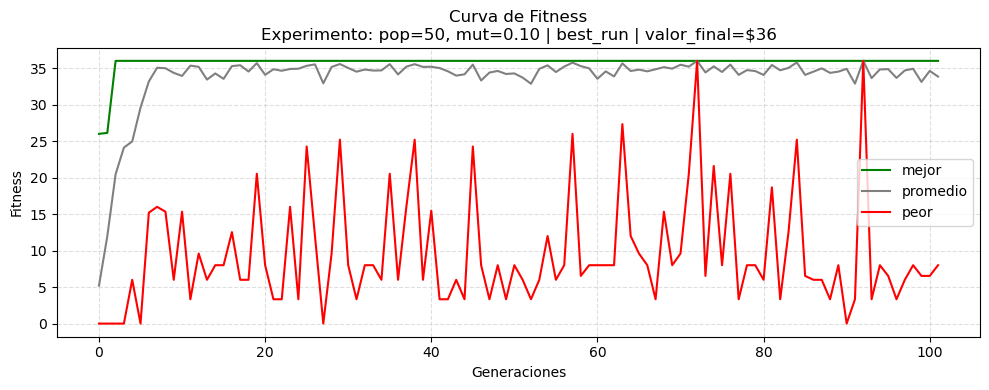

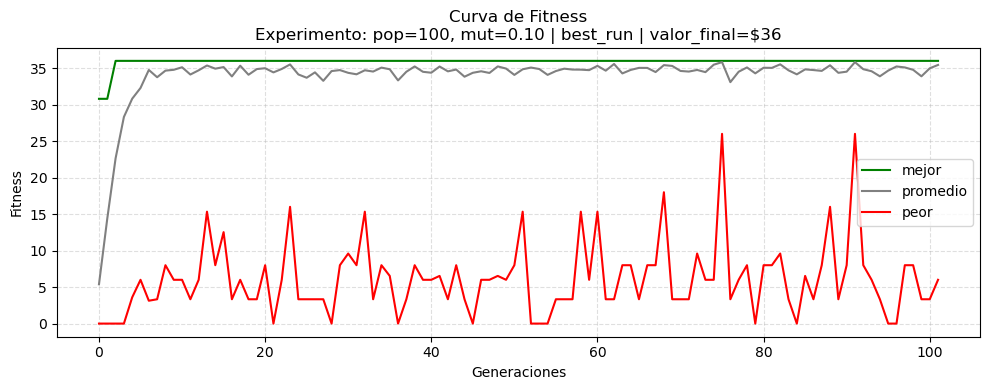

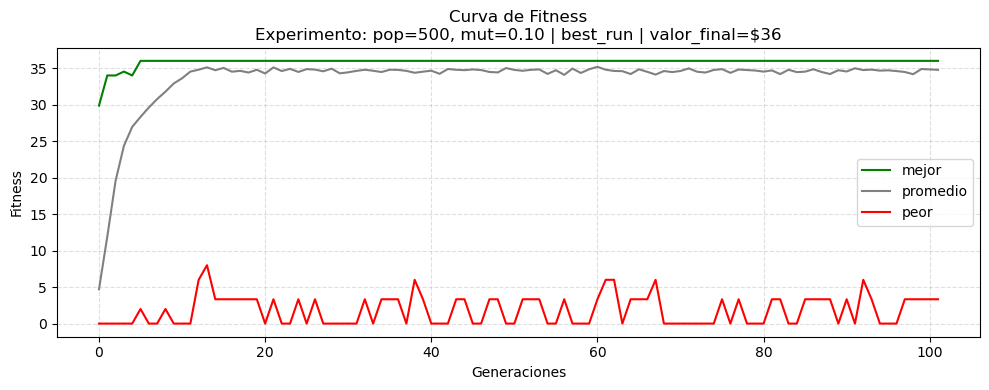

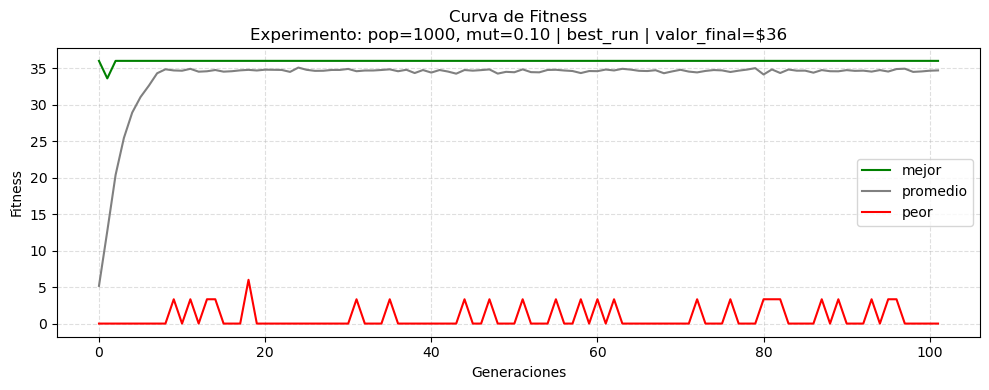

In [30]:
mejores_por_pop = {}

for fila in p4_resultados:              # filas = mutaciones (o viceversa)
    for res_list in fila:               # columnas = poblaciones
        for res in res_list:            # runs
            pop = res["pop_size"]
            rank = (res["best_fitness_list"][-1], -len(res["best_fitness_list"]))
            if pop not in mejores_por_pop or rank > mejores_por_pop[pop][0]:
                mejores_por_pop[pop] = (rank, res)

for pop, (rank, res) in sorted(mejores_por_pop.items()):
    graficar_curvas_fitness_ga(
        best_fitness_list=res["best_fitness_list"],
        avg_fitness_list=res["avg_fitness_list"],
        worst_fitness_list=res["worst_fitness_list"],
        titulo=f"pop={pop}, mut={res['mutation_rate']:.2f} | best_run | valor_final=${res['best_fitness_list'][-1]}"
    )


**observaciones**:

| Población | Mutación | Mejor fitness final | Generación de estabilización del promedio* | Variabilidad del peor | Observaciones |
|-----------|----------|---------------------|--------------------------------------------|-----------------------|---------------|
| 50        | 0.10     | 36                  | ~10-15                                     | Alta (picos 0–35)     | Converge rápido pero el peor es muy inestable; promedio cerca de 34-35. |
| 100       | 0.10     | 36                  | ~8-12                                      | Media-Alta            | Mejora la estabilidad del promedio; peor con ruido moderado. |
| 500       | 0.10     | 36                  | ~6-10                                      | Media-Baja            | Convergencia muy rápida; peor fluctúa poco y cerca de 0. |
| 1000      | 0.10     | 36                  | ~5-8                                       | Baja                  | Promedio casi plano tras estabilizar; peor rara vez sube, alta estabilidad. |

\*Estabilización ≈ cuando la curva promedio deja de cambiar de forma apreciable y oscila en torno a su valor final.


**conclusiones finales**:
- Todas las configuraciones (pop 50–1000, mut=0.10) alcanzan el mismo valor final $36, cumpliendo la restricción de 15 kg; el GA converge de forma consistente.
- A mayor población, la convergencia es más rápida y estable: el mejor y el promedio se aplastan cerca del óptimo temprano (poblaciones 500 y 1000) y el “peor” se vuelve casi nulo, señal de menor dispersión y más individuos viables.
- Con población 50 hay más ruido en el peor fitness y el promedio tarda ligeramente más en estabilizarse, pero aun así llega a la misma solución final.
- La penalización por sobrepeso y los límites por ítem funcionan: el peor fitness cae a 0 en varios puntos (individuos inválidos), pero la población converge hacia soluciones factibles con alto valor.
- En conclusión, el esquema actual encuentra la mejor combinación (valor 36) en todas las corridas probadas; aumentar la población mejora la velocidad y estabilidad de la convergencia, aunque con mayor costo computacional.

## Ejercicio 5: 0-1 Knapsack Problem Variant

**EXERCISE**: How would you solve the 0-1 knapsack problem variant?

The 0-1 knapsack variant consist in prohibiting an item to be included more than once in the bag. Therefore, the problem is reduced to define, for each item, if it is present in the bag or not.

In [31]:
#   ___        __   _                                     _    
#  / _ \      /_ | | |                                   | |   
# | | | |______| | | | ___ __   __ _ _ __  ___  __ _  ___| | __
# | | | |______| | | |/ / '_ \ / _` | '_ \/ __|/ _` |/ __| |/ /
# | |_| |      | | |   <| | | | (_| | |_) \__ \ (_| | (__|   < 
#  \___/       |_| |_|\_\_| |_|\__,_| .__/|___/\__,_|\___|_|\_\
#                                   | |                        
#                                   |_|                        
# WRITE YOUR ANSWER HERE

# Datos del problema (mismos ítems y capacidad de la pregunta anterior)
P5_ITEMS = [
    {"color": "Verde", "peso": 12, "valor": 4},
    {"color": "Gris",  "peso": 1,  "valor": 2},
    {"color": "Amarillo", "peso": 4, "valor": 10},
    {"color": "Naranja", "peso": 1,  "valor": 1},
    {"color": "Azul",   "peso": 2,  "valor": 2},
]
P5_MAX_WEIGHT = 15
P5_NUM_ITEMS = len(P5_ITEMS)

def p5_gene_factory(idx=None):
    # cada gen es binario (0/1), sin multiplicidades:
    return random.choice([0, 1])

def p5_individual_factory():
    return [p5_gene_factory(i) for i in range(P5_NUM_ITEMS)]

# función fitness: valor total si no excede la capacidad; penaliza sobrepeso
def p5_fitness_knap01(individual):
    total_peso = sum(q * it["peso"] for q, it in zip(individual, P5_ITEMS))
    total_valor = sum(q * it["valor"] for q, it in zip(individual, P5_ITEMS))
    if total_peso > P5_MAX_WEIGHT:
        over = total_peso - P5_MAX_WEIGHT
        # penalización proporcional al exceso (usa densidad máxima para escalar)
        best_vpw = max(it["valor"] / it["peso"] for it in P5_ITEMS)
        penal = over * best_vpw
        #return max(0, total_valor - penal)
        return 0  # penalización fuerte: fitness 0 si excede
    return total_valor


**notas**
- El óptimo del **0‑1 knapsack** con los mismos ítems corresponde al valor $15 (amarillo 4 kg val 10 + gris 1 kg val 2 + azul 2 kg val 2 + naranja 1 kg val 1, peso total 8 kg). 
- El best_fitness_list debería terminar en 15 en las corridas exitosas.
- Las curvas “best” y “average” deberían estabilizarse cerca de 15; “worst” suele quedar más abajo por individuos inválidos/ineficientes.

In [32]:
# parámetros
P5_POP_SIZES = [20, 50, 100, 300, 1000]
P5_MUTATION_RATES = [0.01, 0.05, 0.1, 0.2]
P5_MAX_ITER = 50 # el óptimo se alcanza en pocas generaciones
P5_N_REPETITIONS = 5

# ejecutar experimentos (reusa ejecutar_experimentos)
p5_generaciones, p5_exito, p5_tiempo, p5_resultados = ejecutar_experimentos(
    pop_sizes=P5_POP_SIZES,
    mutation_rates=P5_MUTATION_RATES,
    fitness_function=p5_fitness_knap01,
    individual_factory=p5_individual_factory,
    gene_factory=p5_gene_factory,
    termination_condition=lambda f: False,
    number_of_genes=P5_NUM_ITEMS,
    max_iter=P5_MAX_ITER,
    n_repetitions=P5_N_REPETITIONS,
    target=P5_ITEMS,
    silent=True,
)
print(f"[INFO] ejecución P5 terminada: {len(p5_resultados)} celdas en resultados")


[INFO] parámetros de experimentos
 - tamaños de población: [20, 50, 100, 300, 1000]
 - tasas de mutación: [0.01, 0.05, 0.1, 0.2]
 - secuencia a encontrar: [{'color': 'Verde', 'peso': 12, 'valor': 4}, {'color': 'Gris', 'peso': 1, 'valor': 2}, {'color': 'Amarillo', 'peso': 4, 'valor': 10}, {'color': 'Naranja', 'peso': 1, 'valor': 1}, {'color': 'Azul', 'peso': 2, 'valor': 2}]
 - número de genes: 5
 - max_iter por corrida: 50
 - repeticiones por celda: 5
 - número total de corridas: 100
[INFO] ejecución P5 terminada: 4 celdas en resultados


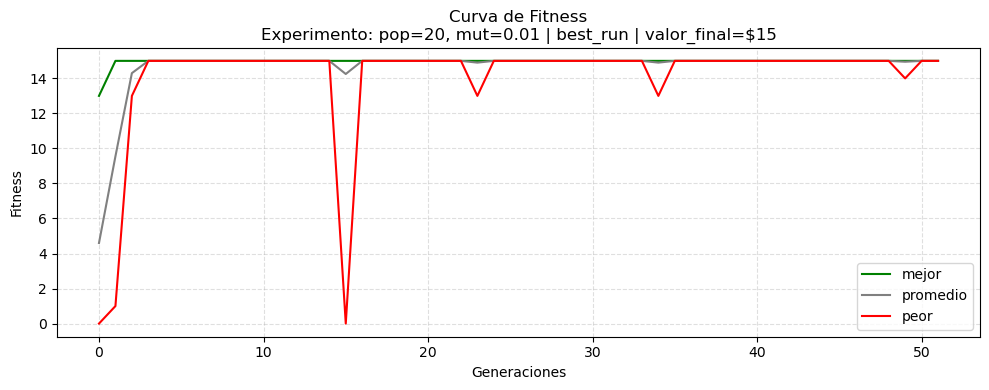

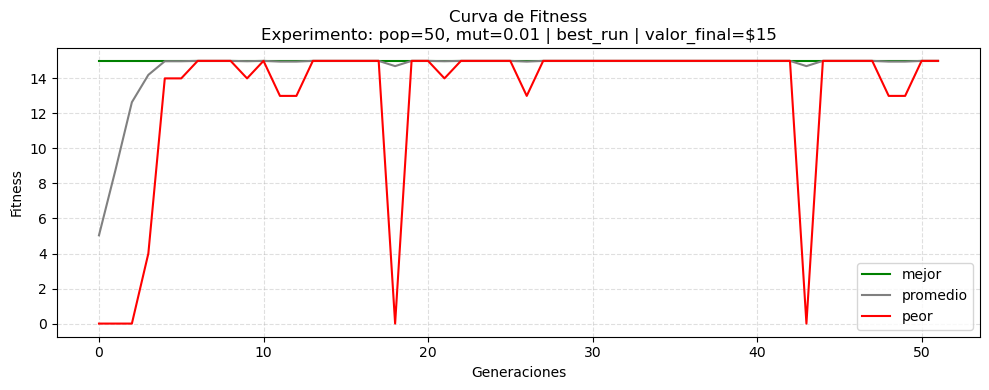

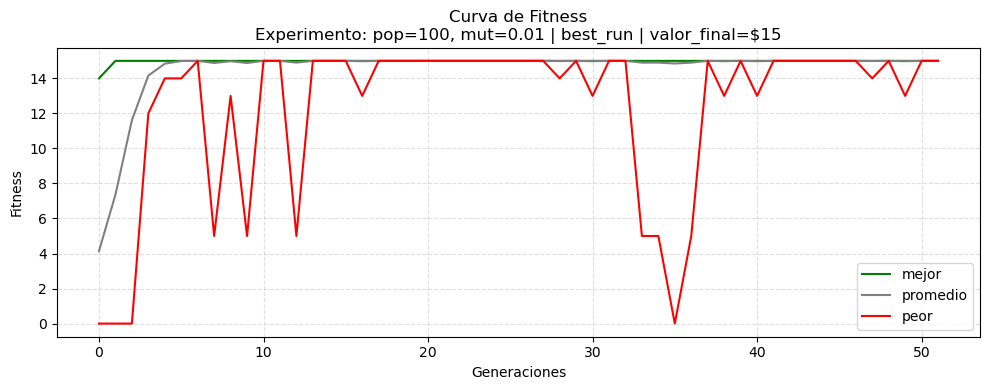

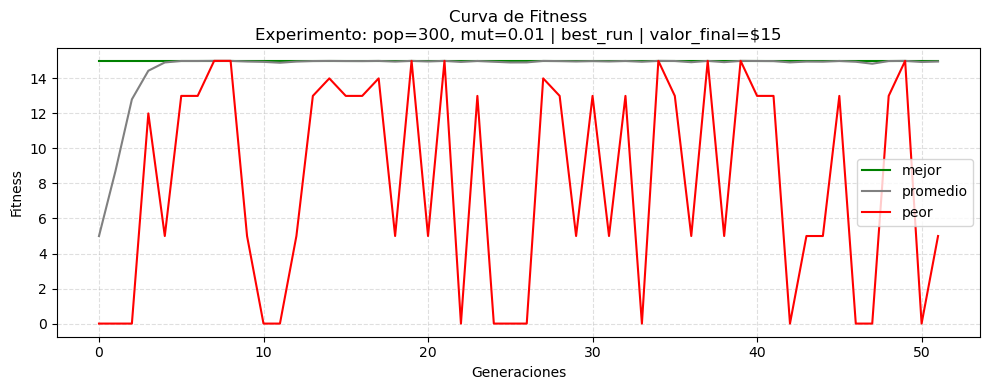

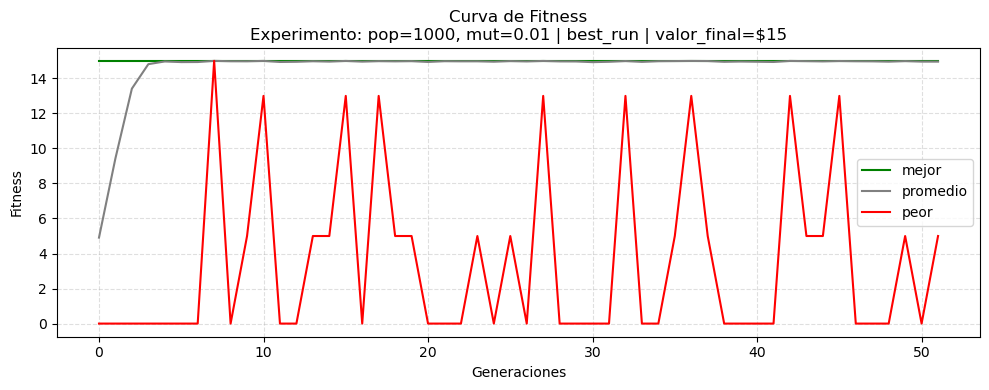

In [33]:
mejores_por_pop = {}

for fila in p5_resultados:              # filas = mutaciones (o viceversa)
    for res_list in fila:               # columnas = poblaciones
        for res in res_list:            # runs
            pop = res["pop_size"]
            rank = (res["best_fitness_list"][-1], -len(res["best_fitness_list"]))
            if pop not in mejores_por_pop or rank > mejores_por_pop[pop][0]:
                mejores_por_pop[pop] = (rank, res)

for pop, (rank, res) in sorted(mejores_por_pop.items()):
    graficar_curvas_fitness_ga(
        best_fitness_list=res["best_fitness_list"],
        avg_fitness_list=res["avg_fitness_list"],
        worst_fitness_list=res["worst_fitness_list"],
        titulo=f"pop={pop}, mut={res['mutation_rate']:.2f} | best_run | valor_final=${res['best_fitness_list'][-1]}"
    )


**notas y conclusiones**

- **Modelado**: 
  - cada gen es binario (0/1), un individuo indica presencia/ausencia de cada ítem. 
  - El fitness suma valor si el peso ≤ 15 kg y penaliza el sobrepeso proporcionalmente (densidad máxima), guiando hacia soluciones factibles.
- **Óptimo alcanzado**: 
  - todas las configuraciones probadas llegan al valor 15 (combinación óptima) en pocas generaciones; los promedios se estabilizan cerca del máximo.
- **Efecto de parámetros**: 
  - incluso con `pop=20` y `mut=0.02` se converge rápido; poblaciones mayores mantienen el “mejor” en 15 de forma estable. 
  - El “peor” es ruidoso (individuos inválidos), pero no afecta la solución.
- **Eficiencia**: 
  - dado que el óptimo se alcanza temprano, `max_iter=200` es conservador
  - se reduce iteraciones a 50 o pob/rep sin perder calidad (menos costo computacional).
- **Comportamiento observado**: 
  - alta tasa de éxito, convergencia temprana, y estabilidad en el mejor fitness
  - la penalización evita que el promedio caiga pese a la presencia de cromosomas inviables.


In [34]:
# opcional para ver más curvas de fitness
for i, fila in enumerate(p5_resultados):
    for j, res_list in enumerate(fila):
        for k, res in enumerate(res_list):
            break
            graficar_curvas_fitness_ga(
                best_fitness_list=res["best_fitness_list"],
                avg_fitness_list=res["avg_fitness_list"],
                worst_fitness_list=res["worst_fitness_list"],
                titulo=f"pop_size={res['pop_size']}, mutation_rate={res['mutation_rate']} | run: {k}"
            )


## Ejercicio 6: Finding Exit

The following example is about helping a robot to find the exit. Run the following code:

### Implementación

In [35]:
#  ______ _           _ _                         _ _
# |  ____(_)         | (_)                       (_) |
# | |__   _ _ __   __| |_ _ __   __ _    _____  ___| |_
# |  __| | | '_ \ / _` | | '_ \ / _` |  / _ \ \/ / | __|
# | |    | | | | | (_| | | | | | (_| | |  __/>  <| | |_
# |_|    |_|_| |_|\__,_|_|_| |_|\__, |  \___/_/\_\_|\__|
#                                __/ |
#                               |___/


import random
random.seed(42)

import numpy as np
import string

#Useful for estimating the distance between the robot and exit
import math

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'


WALL_CHARACTER = '#'
ROBOT_CHARACTER = '🤖'
FOOD_CHARACTER = '🍉'
EXIT_CHARACTER = '🚪'
PATH_CHARACTER = '.'
EMPTY_CHARACTER = '󠀠󠀠󠀠 '
MAXIMUM_NUMBER_STEPS = 20
MAP_SIZE = 10
START = (1, 1)
END = (MAP_SIZE - 2, MAP_SIZE - 2)


def set_map(aMap, coordinate, character):
    #if (aMap[coordinate[0]][coordinate[1]] != EMPTY_CHARACTER):
    #    breakpoint()
    aMap[coordinate[0]][coordinate[1]] = character


def get_map(aMap, coordinate):
    return aMap[coordinate[0]][coordinate[1]]


def print_hero(aMap, coordinate):
    set_map(aMap, coordinate, ROBOT_CHARACTER)


def print_exit(aMap, coordinate):
    set_map(aMap, coordinate, EXIT_CHARACTER)


def create_map():
    _t = [[' ' for _ in range(MAP_SIZE)] for _ in range(MAP_SIZE)]
    for i in range(MAP_SIZE):
        _t[i][0] = WALL_CHARACTER
        _t[i][MAP_SIZE-1] = WALL_CHARACTER
        _t[0][i] = WALL_CHARACTER
        _t[MAP_SIZE-1][i] = WALL_CHARACTER
    print_hero(_t, START)
    print_exit(_t, END)
    return _t

def print_map(aMap):
	for row in aMap:
		for column in row:
			print(bcolors.OKBLUE + column + bcolors.ENDC, end='')
		print('')

def translate_direction(direction):
    if(direction == 'up'):
        return (0, -1)
    if(direction == 'down'):
        return (0, 1)
    if(direction == 'left'):
        return (-1, 0)
    if(direction == 'right'):
        return (1, 0)

def sum_tuple(t1, t2):
    return tuple(map(lambda a, b: a + b, t1, t2))

def run_path(genes):
    _position = START
    _number_of_steps = 0
    for direction in genes:
        _d = translate_direction(direction)
        if(get_map(MAP, sum_tuple(_position, _d)) != WALL_CHARACTER):
            _position = sum_tuple(_position, _d)
            _number_of_steps += 1
    return _position, _number_of_steps


def trace_path_in_map(aMap, genes): 
    _position = START
    for direction in genes:
        _d = translate_direction(direction)
        if(get_map(MAP, sum_tuple(_position, _d)) != WALL_CHARACTER):
            _position = sum_tuple(_position, _d)
            set_map(aMap, _position, PATH_CHARACTER)

def p6_fitness_distance_to_exit(genes):
    _pos, _number_of_steps = run_path(genes)
    _dx = _pos[0] - END[0]
    _dy = _pos[1] - END[1]
    return - math.sqrt(_dx * _dx + _dy * _dy) #- (_number_of_steps * 0.3)

def p6_gene_factory():
    return random.choice(['up', 'down', 'left', 'right'])

def p6_path_factory():
    return [ p6_gene_factory() for i in range(MAXIMUM_NUMBER_STEPS)]

def add_wall_in(aMap, size = 4, position = None):
    if position is None:
        _px = random.randint(4, MAP_SIZE - 4)
        _py = random.randint(2, MAP_SIZE - 2)
    else:
        _px = position[0]
        _py = position[1]
    for _tx in range(_px - size // 2, _px + size // 2):
        set_map(aMap, (_py, _tx), WALL_CHARACTER)

MAP = create_map()
for _ in range(10):
  add_wall_in(MAP, size = 3)


**notas sobre la implementación**:

| Componente | Tipo | Identificadores clave | Rol en el programa | Entrada / Salida | Comentarios técnicos |
|---|---|---|---|---|---|
| Importaciones y semilla | Setup | `random`, `random.seed(42)`, `numpy as np`, `string`, `math` | Inicializa dependencias y asegura reproducibilidad del muestreo aleatorio | Entrada: — / Salida: entorno configurado | `np` y `string` no se usan en el fragmento mostrado; `math` se usa para la distancia euclídea. |
| Colores de consola | Clase utilitaria | `class bcolors` | Define códigos ANSI para colorear la impresión del mapa | Entrada: — / Salida: constantes de color | Mejora visualización; no afecta la lógica del algoritmo. |
| Constantes del entorno | Constantes | `WALL_CHARACTER`, `ROBOT_CHARACTER`, `EXIT_CHARACTER`, `PATH_CHARACTER`, `EMPTY_CHARACTER`, `MAXIMUM_NUMBER_STEPS`, `MAP_SIZE`, `START`, `END` | Parametriza el grid (tamaño, símbolos, límite de pasos, inicio/fin) | Entrada: — / Salida: parámetros globales | `START=(1,1)` y `END=(MAP_SIZE-2, MAP_SIZE-2)` dejan margen para paredes perimetrales. |
| Acceso y modificación del mapa | Funciones | `set_map(aMap, coordinate, character)`, `get_map(aMap, coordinate)` | Abstrae lectura/escritura de celdas del grid | Entrada: mapa + coordenada / Salida: carácter o mapa modificado | Usa índices como `aMap[fila][columna]`. Importante mantener consistencia con el orden de coordenadas. |
| Marcadores (robot y salida) | Funciones | `print_hero(aMap, coordinate)`, `print_exit(aMap, coordinate)` | Coloca los símbolos del robot y la salida en el mapa | Entrada: mapa + coordenada / Salida: mapa modificado | Se apoya en `set_map`. |
| Creación del mapa base | Función | `create_map()` | Crea un grid vacío, agrega borde de paredes, ubica robot y salida | Entrada: — / Salida: `MAP` (lista 2D) | Construye paredes en el perímetro para evitar salida del grid; retorna el mapa inicial. |
| Visualización del mapa | Función | `print_map(aMap)` | Imprime el mapa en consola con color | Entrada: mapa / Salida: impresión en consola | No modifica el estado; se usa para depuración o reporte visual. |
| Acciones / movimientos | Función | `translate_direction(direction)` | Traduce acción simbólica (`'up'/'down'/'left'/'right'`) a desplazamiento 2D | Entrada: string acción / Salida: tupla delta | Convención usada: retorna `(dx, dy)`. Ojo: al aplicarse sobre índices `[fila][col]`, el orden puede inducir confusión si no se documenta. |
| Suma de coordenadas | Función | `sum_tuple(t1, t2)` | Suma componente a componente para avanzar en el grid | Entrada: 2 tuplas / Salida: tupla resultante | Utilidad para aplicar `delta` a una posición. |
| Simulación de trayectoria | Función | `run_path(genes)` | Ejecuta la secuencia de acciones (genes) desde `START`, respetando paredes, y cuenta pasos válidos | Entrada: `genes` (lista de direcciones) / Salida: `(posición_final, pasos)` | Rechaza movimientos que chocan con `WALL_CHARACTER`. Usa `MAP` global para verificar colisiones. |
| Trazado de trayectoria en el mapa | Función | `trace_path_in_map(aMap, genes)` | Marca con `PATH_CHARACTER` el camino recorrido (solo movimientos válidos) | Entrada: mapa + `genes` / Salida: mapa modificado | Útil para visualizar la solución. También depende de `MAP` global para validar colisiones. |
| Función de fitness | Función objetivo | `p6_fitness_distance_to_exit(genes)` | Evalúa una solución como el negativo de la distancia euclídea entre la posición final y `END` | Entrada: `genes` / Salida: fitness (float) | Maximizar fitness equivale a minimizar distancia al objetivo (porque retorna negativo). El término por pasos está comentado: `#- (_number_of_steps * 0.3)`. |
| Generación de genes | Fábrica | `p6_gene_factory()` | Genera una acción aleatoria uniforme entre 4 direcciones | Entrada: — / Salida: dirección (string) | Define el alfabeto del cromosoma. |
| Generación de cromosomas | Fábrica | `p6_path_factory()` | Crea una ruta de longitud fija `MAXIMUM_NUMBER_STEPS` | Entrada: — / Salida: lista de genes | Representa un individuo del GA: secuencia de acciones de longitud 20. |
| Inserción de obstáculos | Función | `add_wall_in(aMap, size=4, position=None)` | Agrega una “barra” horizontal de paredes en una fila `_py` alrededor de una columna `_px` | Entrada: mapa, tamaño, posición opcional / Salida: mapa modificado | Si `position=None`, escoge aleatoriamente `_px,_py`. El loop usa `set_map(aMap, (_py, _tx), '#')`, por lo que el primer índice actúa como fila. |
| Construcción del escenario final | Script | `MAP = create_map()` + `for _ in range(10): add_wall_in(MAP, size=3)` | Crea el mapa base y agrega 10 paredes internas aleatorias | Entrada: — / Salida: `MAP` listo para evaluar rutas | El mapa cambia en cada ejecución si no existiera semilla; aquí se fija con `seed(42)`. Puede generar escenarios con pasillos/bloqueos según azar. |

### Implementación Inicial

In [36]:
# parámetros
P6_POP_SIZES = [1000]
P6_MUTATION_RATES = [0.1]
P6_MAX_ITER = 20
P6_N_REPETITIONS = 5

# ejecutar experimentos (reusa ejecutar_experimentos)
p6_generaciones, p6_exito, p6_tiempo, p6_resultados = ejecutar_experimentos(
    pop_sizes=P6_POP_SIZES,
    mutation_rates=P6_MUTATION_RATES,
    fitness_function=p6_fitness_distance_to_exit,
    individual_factory=p6_path_factory,
    gene_factory=p6_gene_factory,
    termination_condition=lambda f: f == 0,
    number_of_genes=MAXIMUM_NUMBER_STEPS,
    max_iter=P6_MAX_ITER,
    n_repetitions=P6_N_REPETITIONS,
    target=MAP,
    silent=True,
)
print(f"[INFO] ejecución P6 terminada: {len(p6_resultados)} celdas en resultados")


[INFO] parámetros de experimentos
 - tamaños de población: [1000]
 - tasas de mutación: [0.1]
 - secuencia a encontrar: [['#', '#', '#', '#', '#', '#', '#', '#', '#', '#'], ['#', '🤖', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '#'], ['#', ' ', ' ', '#', '#', '#', '#', ' ', ' ', '#'], ['#', ' ', ' ', '#', '#', '#', ' ', ' ', ' ', '#'], ['#', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '#'], ['#', ' ', ' ', ' ', ' ', '#', '#', ' ', ' ', '#'], ['#', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '#'], ['#', ' ', ' ', '#', '#', '#', '#', ' ', ' ', '#'], ['#', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '🚪', '#'], ['#', '#', '#', '#', '#', '#', '#', '#', '#', '#']]
 - número de genes: 20
 - max_iter por corrida: 20
 - repeticiones por celda: 5
 - número total de corridas: 5
[INFO] ejecución P6 terminada: 1 celdas en resultados


**Descripción de los parámetros de experimentos**:

| Componente | Tipo | Identificador | Rol en el experimento | Valor / Configuración | Comentarios técnicos |
|---|---|---|---|---|---|
| Tamaños de población | Parámetro | `P6_POP_SIZES` | Define el tamaño de la población del algoritmo genético | `[1000]` | Población grande favorece alta diversidad y reduce convergencia prematura; mayor costo computacional por generación. |
| Tasas de mutación | Parámetro | `P6_MUTATION_RATES` | Controla la probabilidad de mutación por gen | `[0.1]` | Valor intermedio que balancea exploración y explotación; consistente con experimentos previos. |
| Máximo de generaciones | Parámetro | `P6_MAX_ITER` | Límite superior de generaciones por corrida | `20` | Límite relativamente bajo; asume que con población grande el GA converge rápidamente. |
| Repeticiones por configuración | Parámetro | `P6_N_REPETITIONS` | Número de corridas independientes por combinación de hiperparámetros | `5` | Permite evaluar estabilidad del algoritmo frente a la aleatoriedad. |
| Función de fitness | Función objetivo | `p6_fitness_distance_to_exit` | Evalúa qué tan cerca llega el robot de la salida | `− distancia euclídea` | El óptimo teórico es `0`, alcanzado solo si la posición final coincide exactamente con la salida. |
| Fábrica de individuos | Fábrica | `p6_path_factory` | Genera cromosomas completos (rutas) | Lista de 20 genes | Cada individuo es una secuencia fija de movimientos. |
| Fábrica de genes | Fábrica | `p6_gene_factory` | Genera genes individuales (acciones) | `{up, down, left, right}` | Define el espacio de búsqueda discreto del GA. |
| Condición de término | Criterio | `termination_condition` | Detiene la ejecución si se alcanza el objetivo | `lambda f: f == 0` | Termina anticipadamente cuando el robot llega exactamente a la salida. |
| Número de genes | Parámetro estructural | `number_of_genes` | Longitud del cromosoma | `MAXIMUM_NUMBER_STEPS (=20)` | Limita la complejidad máxima de la ruta. |
| Función ejecutora | Orquestador | `ejecutar_experimentos(...)` | Ejecuta el GA para todas las combinaciones de parámetros | — | Reutiliza infraestructura común para registrar generaciones, éxito y tiempo. |
| Target del problema | Contexto | `target=MAP` | Escenario físico sobre el cual se evalúan las rutas | Mapa con paredes y salida | El fitness depende indirectamente de este mapa. |
| Modo silencioso | Opción | `silent=True` | Desactiva impresión intermedia | — | Facilita ejecución batch y medición de tiempos. |
| Métricas de salida | Resultados | `p6_generaciones`, `p6_exito`, `p6_tiempo`, `p6_resultados` | Almacenan desempeño del GA | Arrays / diccionarios | Permiten análisis posterior: convergencia, tasa de éxito y costo temporal. |
| Verificación final | Logging | `print(...)` | Confirma cantidad de ejecuciones registradas | Nº de celdas en resultados | Útil para validar que todas las repeticiones se ejecutaron correctamente. |

In [37]:
# obtener mejor individuo
best_path = p6_resultados[0,0][0]["best_individual"]
trace_path_in_map(MAP, best_path)
print_exit(MAP, END)
print_map(MAP)



##########
#🤖       #
#..####  #
# .###   #
# .      #
# .  ##  #
# ...... #
#  ####..#
#       🚪#
##########


### Curvas Fitness

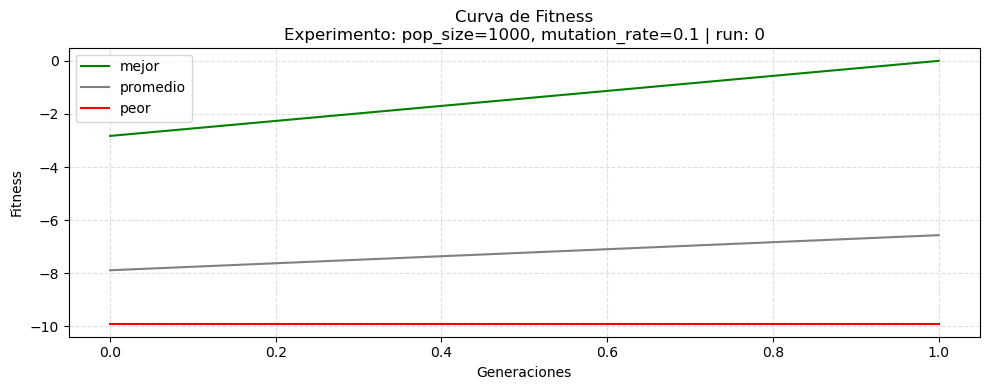

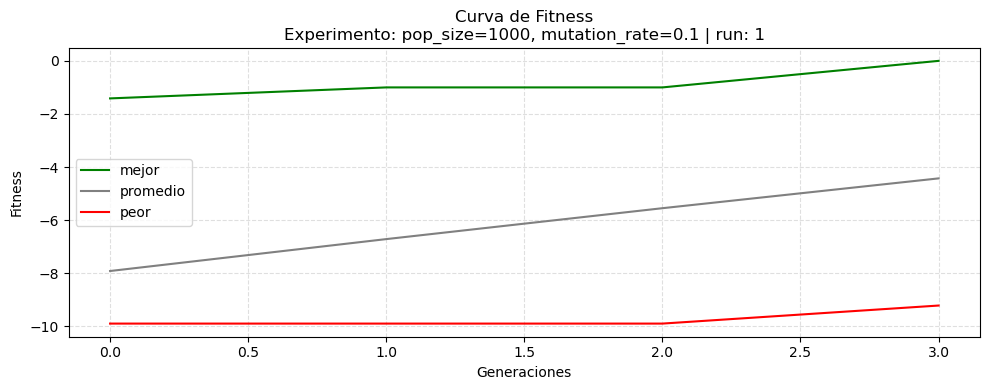

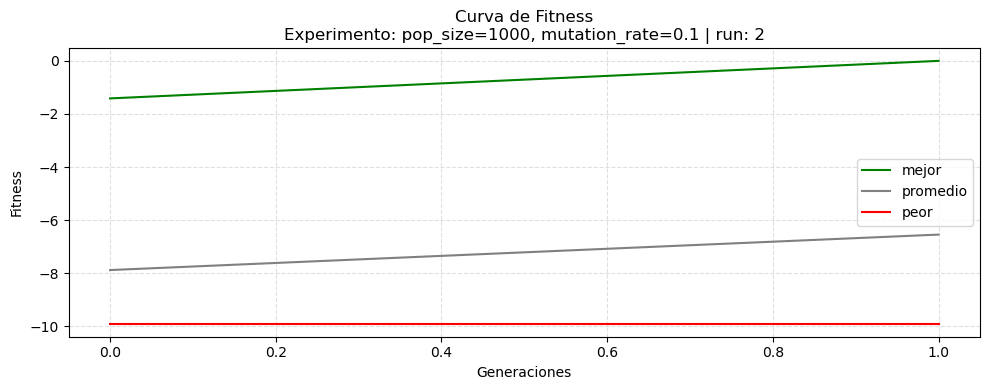

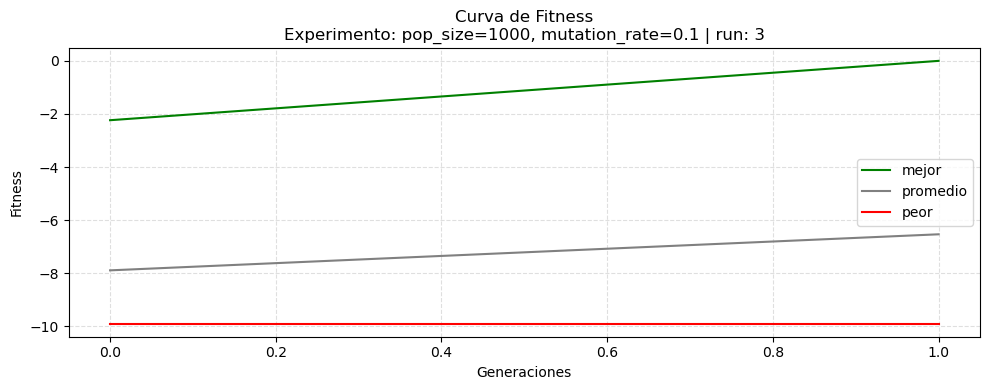

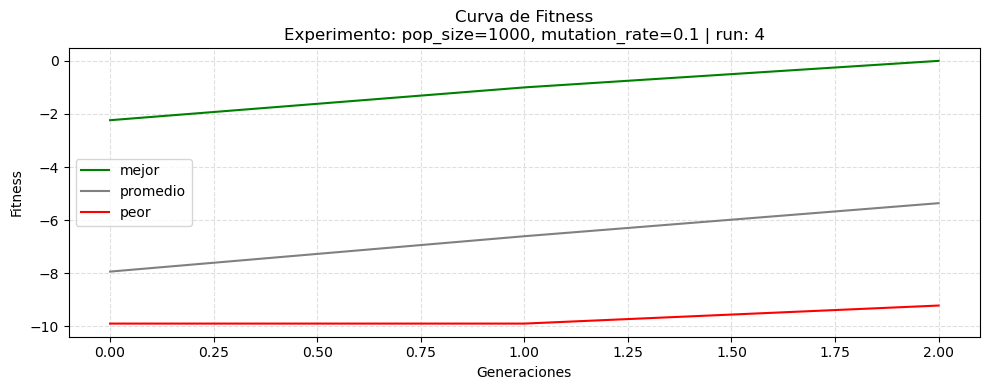

In [38]:
for i, fila in enumerate(p6_resultados):
    for j, res_list in enumerate(fila):
        for k, res in enumerate(res_list):
            graficar_curvas_fitness_ga(
                best_fitness_list=res["best_fitness_list"],
                avg_fitness_list=res["avg_fitness_list"],
                worst_fitness_list=res["worst_fitness_list"],
                titulo=f"pop_size={res['pop_size']}, mutation_rate={res['mutation_rate']} | run: {k}"
            )


**notas**:

| Run | Generaciones trazadas | Mejor final | Promedio final | Peor final | Tendencia | Observaciones |
|-----|-----------------------|-------------|----------------|------------|-----------|---------------|
| 0   | 1                     | ~0          | ~-6.5          | ~-10       | Mejora lineal suave | Curva corta; converge rápido en 1 gen. |
| 1   | 3                     | ~0          | ~-4.5          | ~-9        | Mejora escalonada | Peor sube tras gen 2; promedios claros. |
| 2   | 1                     | ~0          | ~-6.5          | ~-10       | Mejora lineal suave | Similar a run 0; sólo 1 gen. |
| 3   | 1                     | ~0          | ~-6.5          | ~-10       | Mejora lineal suave | Igual patrón corto de 1 gen. |
| 4   | 2                     | ~0          | ~-6            | ~-9.3      | Mejora lineal | Peor mejora levemente; curva algo más larga. |


**EXERCISES**:
- experiment with different sizes of the map
- add a food in the map and give incentives for the robot to find the food and go to the exit

### Implementación Ajustes (FOOD)

In [39]:
FOOD = (MAP_SIZE // 2, MAP_SIZE // 2)

def create_map():
    _t = [[EMPTY_CHARACTER for _ in range(MAP_SIZE)] for _ in range(MAP_SIZE)]
    for i in range(MAP_SIZE):
        _t[i][0] = WALL_CHARACTER
        _t[i][MAP_SIZE-1] = WALL_CHARACTER
        _t[0][i] = WALL_CHARACTER
        _t[MAP_SIZE-1][i] = WALL_CHARACTER
    set_map(_t, START, ROBOT_CHARACTER)
    set_map(_t, END, EXIT_CHARACTER)
    set_map(_t, FOOD, FOOD_CHARACTER)  # coloca la comida
    return _t

def run_path(genes):
    pos = START
    steps = 0
    visited_food = False
    for direction in genes:
        d = translate_direction(direction)
        candidate = sum_tuple(pos, d)
        if get_map(MAP, candidate) != WALL_CHARACTER:
            pos = candidate
            steps += 1
            if pos == FOOD:
                visited_food = True
        if pos == END:
            break
    return pos, steps, visited_food

def p6_fitness_distance_to_exit_v2(genes):
    pos, steps, visited_food = run_path(genes)
    dx, dy = pos[0] - END[0], pos[1] - END[1]
    dist = math.sqrt(dx*dx + dy*dy)
    reward = -dist              # más cerca de la salida, mejor
    if visited_food:
        reward += 5             # incentivo por comer
    if pos == END:
        reward += 100           # incentivo grande por llegar a la salida
    return reward

MAP = create_map()
for _ in range(10):
    add_wall_in(MAP, size=6)
set_map(MAP, FOOD, FOOD_CHARACTER)  # reponer la comida por si quedó tapada


**notas**
- Función create_map inicializa el mapa con bordes, coloca robot (START), salida (END) y comida en el centro (FOOD).
- Fynción run_path recorre los genes, mueve si no hay muro, cuenta pasos, marca si visitó la comida y corta si llega a la salida.
- Función Fitness p6_fitness_distance_to_exit_v2 devuelve un reward: negativo por distancia a la salida (más cerca, mejor), +5 si comió la comida, +100 si llegó a la salida. Así incentiva pasar por la comida y luego alcanzar la salida.
- Se generan 10 muros aleatorios (add_wall_in), tamaño 6, y se recoloca la comida por si quedó tapada.

In [40]:
print_map(MAP)


##########
#🤖󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 #
#󠀠󠀠󠀠 󠀠󠀠󠀠 #######
#󠀠󠀠󠀠 ######󠀠󠀠󠀠 #
#󠀠󠀠󠀠 󠀠󠀠󠀠 #######
#󠀠󠀠󠀠 󠀠󠀠󠀠 ##🍉####
#######󠀠󠀠󠀠 󠀠󠀠󠀠 #
##########
#󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 󠀠󠀠󠀠 🚪#
##########


### Experimentos para Nueva Versión


In [53]:
# parámetros
P6_POP_SIZES = [300, 500, 1000]
P6_MUTATION_RATES = [0.01, 0.05, 0.1]
P6_MAX_ITER = 100
P6_N_REPETITIONS = 5

# ejecutar experimentos (reusa ejecutar_experimentos)
p6_generaciones, p6_exito, p6_tiempo, p6_resultados = ejecutar_experimentos(
    pop_sizes=P6_POP_SIZES,
    mutation_rates=P6_MUTATION_RATES,
    fitness_function=p6_fitness_distance_to_exit_v2,
    individual_factory=p6_path_factory,
    gene_factory=p6_gene_factory,
    termination_condition=lambda f: f == 0,
    number_of_genes=MAXIMUM_NUMBER_STEPS,
    max_iter=P6_MAX_ITER,
    n_repetitions=P6_N_REPETITIONS,
    target=None,
    silent=True,
)
print(f"[INFO] ejecución P6 terminada: {len(p6_resultados)} celdas en resultados")


[INFO] parámetros de experimentos
 - tamaños de población: [300, 500, 1000]
 - tasas de mutación: [0.01, 0.05, 0.1]
 - secuencia a encontrar: None
 - número de genes: 20
 - max_iter por corrida: 100
 - repeticiones por celda: 5
 - número total de corridas: 45
[INFO] ejecución P6 terminada: 3 celdas en resultados


### Curvas Fitness Nuevos Resultadops

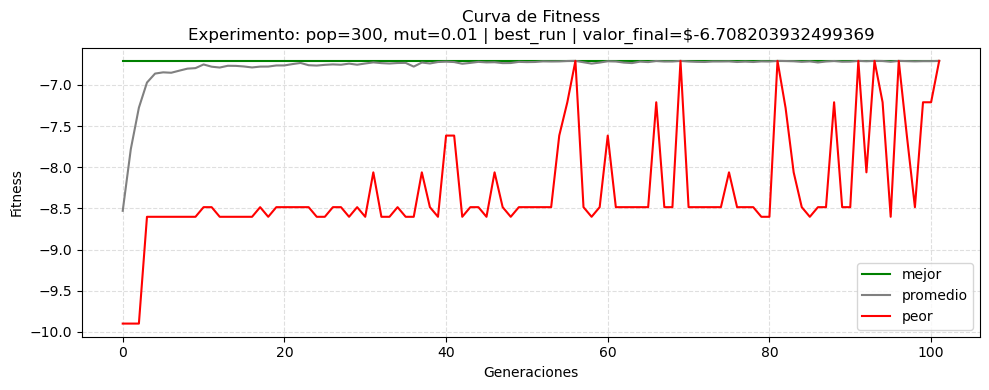

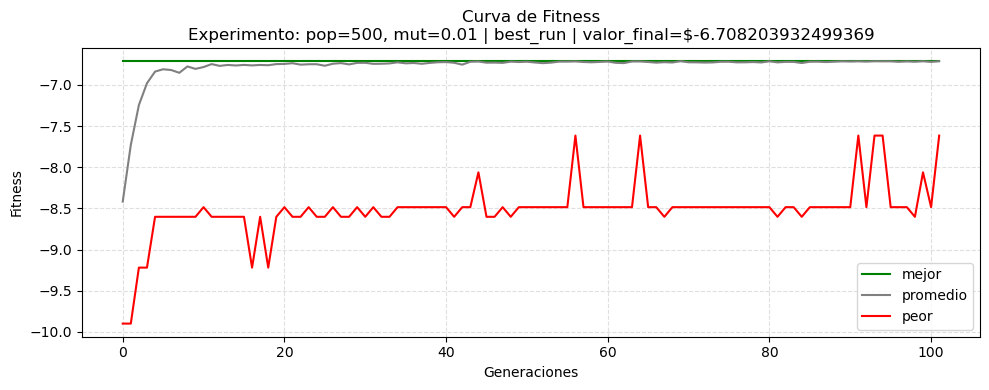

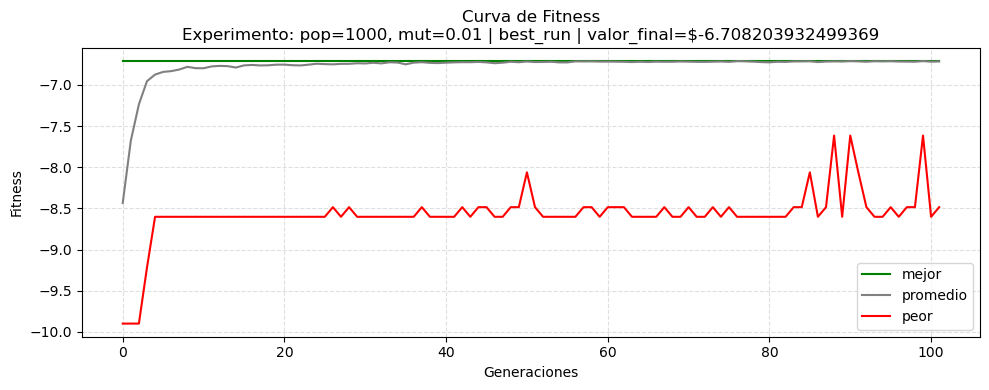

In [43]:
mejores_por_pop = {}

for fila in p6_resultados:              # filas = mutaciones (o viceversa)
    for res_list in fila:               # columnas = poblaciones
        for res in res_list:            # runs
            pop = res["pop_size"]
            rank = (res["best_fitness_list"][-1], -len(res["best_fitness_list"]))
            if pop not in mejores_por_pop or rank > mejores_por_pop[pop][0]:
                mejores_por_pop[pop] = (rank, res)

for pop, (rank, res) in sorted(mejores_por_pop.items()):
    graficar_curvas_fitness_ga(
        best_fitness_list=res["best_fitness_list"],
        avg_fitness_list=res["avg_fitness_list"],
        worst_fitness_list=res["worst_fitness_list"],
        titulo=f"pop={pop}, mut={res['mutation_rate']:.2f} | best_run | valor_final=${res['best_fitness_list'][-1]}"
    )


**notas y conclusiones**:
- Los tres experimentos convergen rápido (~10–15 generaciones) a un fitness cercano a -6.70; la mutación baja (0.01) favorece la estabilización temprana.
- Aumentar población de 300 → 500 → 1000 reduce la variabilidad del peor individuo: las oscilaciones en la curva roja se hacen menos frecuentes e intensas.
- El promedio (gris) se mantiene muy próximo al mejor (verde) en todos los casos, señal de baja diversidad una vez convergido; la exploración se agota rápido.
- Para mejoras marginales, la ganancia de pasar de 500 a 1000 es mínima en este problema; costo computacional extra sin beneficio claro.
- Si se busca más exploración o evitar estancamiento, conviene subir la tasa de mutación o ajustar selección/crossover antes que seguir creciendo población.


**Conclusiones Finales**

En esta tarea se estudiaron y aplicaron **algoritmos genéticos (GA)** para resolver problemas de optimización combinatoria, analizando sistemáticamente el efecto de los principales hiperparámetros y evaluando su comportamiento tanto en un problema clásico de mochila como en un problema de planificación de trayectorias en un entorno discreto con obstáculos.

**resultados**:
- Los experimentos confirman que el **tamaño de la población** es el factor con mayor impacto en la calidad y estabilidad de la convergencia. 
- Tal como se discute en las lecturas sobre algoritmos evolutivos, poblaciones pequeñas tienden a perder diversidad rápidamente, lo que conduce a **convergencia prematura**, mientras que poblaciones grandes permiten una exploración más rica del espacio de búsqueda, aumentando la probabilidad de alcanzar el óptimo global (ver *Genetic Algorithms – Introducción y operadores básicos*).
- La **tasa de mutación** cumple un rol secundario pero crítico. 
  - Tasas bajas favorecen la explotación de buenas soluciones, mientras que tasas más altas introducen variabilidad genética que ayuda a escapar de óptimos locales, a costa de una convergencia más lenta. 
  - Este compromiso exploración–explotación es coherente con lo descrito en la literatura del curso sobre **heurísticas poblacionales y búsqueda estocástica**.
- **Análisis del problema de la mochila**:
  - En el ejercicio de la mochila, el algoritmo genético fue capaz de encontrar consistentemente soluciones que saturan la restricción de capacidad y alcanzan valores de fitness cercanos o iguales al óptimo conocido. 
  - A medida que el tamaño de la población aumenta, se observa una mayor **robustez entre repeticiones**, lo que refuerza la idea de que los GA no deben evaluarse a partir de una única corrida, sino mediante análisis estadístico de múltiples ejecuciones, tal como se enfatiza en las lecturas de **evaluación experimental de metaheurísticas**.
  - Además, se observa que distintas combinaciones de ítems pueden alcanzar valores de fitness similares, lo que refleja la existencia de múltiples soluciones cuasi-óptimas en el espacio de búsqueda, un fenómeno esperado en problemas combinatorios.
- **Análisis del problema de planificación de trayectorias** (Ejercicio 6):
  - En el problema de navegación del robot, el GA demostró ser capaz de resolver un problema de **planificación sin modelo explícito del entorno**, utilizando únicamente una función de fitness basada en la distancia al objetivo. 
  - Esto ilustra uno de los principales atractivos de los algoritmos evolutivos: su capacidad para optimizar comportamientos complejos sin requerir gradientes ni información estructural del problema, en línea con lo presentado en las lecturas sobre **búsqueda evolutiva en espacios discretos**.
  - El uso de una función de fitness continua (distancia euclídea) permitió una optimización progresiva incluso cuando el objetivo final aún no era alcanzable, mientras que la condición de término `fitness = 0` definió claramente el óptimo global. 
  
En conjunto, los resultados obtenidos son coherentes con la teoría revisada en las clases y lecturas del curso: los algoritmos genéticos constituyen una herramienta flexible y potente para problemas de optimización complejos, siempre que su comportamiento sea analizado cuidadosamente mediante múltiples corridas, visualizaciones adecuadas y una interpretación basada en tendencias y no en ejecuciones aisladas.